In [29]:
"""
Representational Similarity Analysis (RSA) for recalled word transitions
— Broadband version (no band separation) —
------------------------------------------------------------------------
Input : ALL_SUBJECTS_irasa_clean.csv   ← must be LONG FORMAT
                                         one row per word × region × frequency
Output: ALL_SUBJECTS_word_level_rsa.csv

RSA definition:
    For each word i, RSA = Pearson r between the full broadband pattern
    vectors of word i and word i+1.
    Pattern vector = [LHP_f0..fK, RHP_f0..fK] across ALL frequencies.
    Stored at row i. Last word in each trial is skipped (no next word).

One RSA value per phase × component combination:
    rsa_frac_encoding, rsa_osc_encoding,
    rsa_frac_retrieval, rsa_osc_retrieval
"""

import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_irasa_clean.csv'
OUTPUT_CSV = 'ALL_SUBJECTS_word_level_rsa.csv'

HP_REGIONS  = ['LHP', 'RHP']
ALL_REGIONS = ['LHP', 'RHP', 'LEC', 'REC', 'LPC', 'RPC']
PHASES      = ['encoding', 'retrieval']
COMPONENTS  = ['frac', 'osc']

WORD_META_COLS = [
    'subject', 'session', 'trial', 'recalled_word',
    'recall_stim', 'encoding_stim',
    'SP_clustering_from_prev', 'SP_clustering_to_next',
    'T_clustering_from_prev',  'T_clustering_to_next',
]

WORD_KEY = ['subject', 'session', 'trial', 'recalled_word']

FREQ_COL = 'freq_hz'    # actual Hz column in ALL_SUBJECTS_irasa_clean.csv

# ============================================================================
# HELPERS
# ============================================================================

def safe_pearson(v1, v2):
    """Pearson r; returns NaN if < 2 valid pairs or zero variance."""
    v1, v2 = np.array(v1, dtype=float), np.array(v2, dtype=float)
    mask = ~(np.isnan(v1) | np.isnan(v2))
    if mask.sum() < 2:
        return np.nan
    a, b = v1[mask], v2[mask]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    r, _ = pearsonr(a, b)
    return r


def build_pattern_vector(word_df, phase, comp, freq_axis):
    """
    Build broadband pattern vector [LHP_f0..fK, RHP_f0..fK] for one word.
    Uses ALL frequencies in freq_axis.
    Returns array of length 2 * len(freq_axis).
    """
    col = f'{phase}_{comp}_ssl'
    n   = len(freq_axis)
    vec = np.full(len(HP_REGIONS) * n, np.nan)

    for r_idx, region in enumerate(HP_REGIONS):
        region_rows = word_df[word_df['region'] == region]
        for local_i, hz in enumerate(freq_axis):
            match = region_rows[np.isclose(region_rows[FREQ_COL], hz)]
            if len(match):
                vec[r_idx * n + local_i] = match.iloc[0][col]
    return vec


def mean_power(word_df, region, phase, comp):
    col  = f'{phase}_{comp}_ssl'
    vals = word_df.loc[word_df['region'] == region, col].values
    return np.nan if len(vals) == 0 else np.nanmean(vals)


# ============================================================================
# LOAD & VALIDATE
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows loaded")

assert FREQ_COL in df.columns, (
    f"Input CSV is missing the '{FREQ_COL}' column. "
    "Expected long-format data (one row per word × region × frequency)."
)

real_freqs = df[FREQ_COL].dropna()
real_freqs = real_freqs[real_freqs > 0]
assert len(real_freqs) > 0, (
    f"All '{FREQ_COL}' values are <= 0 (likely -999 sentinels). "
    "Please supply the original long-format IRASA CSV."
)

rows_per_word = df.groupby(WORD_KEY).size()
assert (rows_per_word > 1).any(), (
    "Every WORD_KEY group has exactly 1 row. "
    "Please supply the original long-format IRASA CSV."
)

freq_axis = np.sort(real_freqs.unique())
print(f"  {len(freq_axis)} frequencies: {np.round(freq_axis, 2).tolist()}")
print(f"  Pattern vector length per word: {len(HP_REGIONS) * len(freq_axis)}")

# ============================================================================
# STEP 1 — Collapse to one row per word
# ============================================================================

print("\nCollapsing to word level ...")

df['_orig_order'] = np.arange(len(df))
word_records = []

for word_key, word_df in df.groupby(WORD_KEY, sort=False):
    record = dict(zip(WORD_KEY, word_key))

    first = word_df.iloc[0]
    for col in WORD_META_COLS:
        if col not in WORD_KEY and col in word_df.columns:
            record[col] = first[col]

    record['_orig_order'] = word_df['_orig_order'].min()

    # mean power per region × phase × component (broadband)
    for region in ALL_REGIONS:
        for phase in PHASES:
            for comp in COMPONENTS:
                record[f'{region}_mean_{comp}_{phase}'] = mean_power(
                    word_df, region, phase, comp
                )

    # broadband pattern vectors for RSA (all frequencies, no band split)
    hp_df = word_df[word_df['region'].isin(HP_REGIONS)]
    for phase in PHASES:
        for comp in COMPONENTS:
            record[f'_vec_{phase}_{comp}'] = \
                build_pattern_vector(hp_df, phase, comp, freq_axis)

    word_records.append(record)

word_level = pd.DataFrame(word_records)
print(f"  {len(word_level):,} unique word events")

# ============================================================================
# STEP 2 — Assign recall order and compute RSA
# ============================================================================

print("Assigning recall order ...")

word_level = word_level.sort_values(
    ['subject', 'session', 'trial', '_orig_order']
).reset_index(drop=True)

rsa_cols = [f'rsa_{comp}_{phase}' for phase in PHASES for comp in COMPONENTS]
for col in rsa_cols:
    word_level[col] = np.nan

print("Computing broadband RSA (word i vs word i+1) ...")

for (subj, sess, trial), t_df in word_level.groupby(
        ['subject', 'session', 'trial'], sort=False):
    idx_list = t_df.index.tolist()

    for i, idx in enumerate(idx_list):
        if i == len(idx_list) - 1:
            continue   # last word has no next — skip

        next_idx = idx_list[i + 1]

        for phase in PHASES:
            for comp in COMPONENTS:
                key = f'_vec_{phase}_{comp}'
                r = safe_pearson(
                    word_level.at[idx,      key],   # word i
                    word_level.at[next_idx, key],   # word i+1
                )
                word_level.at[idx, f'rsa_{comp}_{phase}'] = r

print("\nRSA non-null counts:")
for col in rsa_cols:
    print(f"  {col:<30} non-null: {word_level[col].notna().sum():,}")

# ============================================================================
# STEP 3 — Clean up and save
# ============================================================================

mean_power_cols = [
    f'{region}_mean_{comp}_{phase}'
    for region in ALL_REGIONS
    for phase in PHASES
    for comp in COMPONENTS
]

final_cols = WORD_META_COLS + rsa_cols + mean_power_cols
final_cols = [c for c in final_cols if c in word_level.columns]
word_level = word_level[final_cols]

word_level.to_csv(OUTPUT_CSV, index=False)

print(f"\n✓ Saved {len(word_level):,} rows → {OUTPUT_CSV}")
print(f"\nColumns ({len(word_level.columns)}):")
for col in word_level.columns:
    print(f"  {col}")
print(f"\nSample (first 5 rows):")
print(word_level.head().to_string(index=False))

Loading ALL_SUBJECTS_irasa_clean.csv ...
  28,836 rows loaded
  18 frequencies: [3.0, 3.74, 4.67, 5.82, 7.26, 9.05, 11.28, 14.07, 17.55, 21.88, 27.29, 34.03, 42.44, 52.92, 66.0, 82.31, 102.64, 128.0]
  Pattern vector length per word: 36

Collapsing to word level ...


KeyboardInterrupt: 

In [18]:
import pandas as pd
df = pd.read_csv('ALL_SUBJECTS_irasa_clean.csv', nrows=20)
print(df.shape)
print(df.columns.tolist())
print()
print(df[['subject','session','trial','recalled_word','region','frequency']].head(20))
print()
print('frequency unique (first 20):', df['frequency'].unique()[:20])
print('rows per word key:')
print(df.groupby(['subject','session','trial','recalled_word']).size().value_counts().head())

(20, 18)
['subject', 'session', 'trial', 'recalled_word', 'region', 'freq_hz', 'freq_idx', 'SP_clustering_from_prev', 'SP_clustering_to_next', 'T_clustering_from_prev', 'T_clustering_to_next', 'recall_stim', 'encoding_stim', 'frequency', 'encoding_frac_ssl', 'encoding_osc_ssl', 'retrieval_frac_ssl', 'retrieval_osc_ssl']

   subject  session  trial   recalled_word region  frequency
0   R1494D        0      0  GUITAR_STRINGS    RHP       -999
1   R1494D        0      0  GUITAR_STRINGS    RHP       -999
2   R1494D        0      0  GUITAR_STRINGS    RHP       -999
3   R1494D        0      0  GUITAR_STRINGS    RHP       -999
4   R1494D        0      0  GUITAR_STRINGS    RHP       -999
5   R1494D        0      0  GUITAR_STRINGS    RHP       -999
6   R1494D        0      0  GUITAR_STRINGS    RHP       -999
7   R1494D        0      0  GUITAR_STRINGS    RHP       -999
8   R1494D        0      0  GUITAR_STRINGS    RHP       -999
9   R1494D        0      0  GUITAR_STRINGS    RHP       -999
10  R1

In [33]:
"""
Linear Mixed Models: Clustering scores → Representational Similarity
---------------------------------------------------------------------
Input : ALL_SUBJECTS_word_level_rsa.csv  (one row per recalled word)

RSA outcome = pearson_r(vector[A-1], vector[A+1])  ← neural neighborhood similarity
Predictors  = from_prev clustering scores only, matching the A-1 → A transition

Models (4 total, one per RSA outcome):
    rsa_frac_encoding  ~ SP_clustering_from_prev + T_clustering_from_prev
    rsa_osc_encoding   ~ SP_clustering_from_prev + T_clustering_from_prev
    rsa_frac_retrieval ~ SP_clustering_from_prev + T_clustering_from_prev
    rsa_osc_retrieval  ~ SP_clustering_from_prev + T_clustering_from_prev

Conceptual alignment:
    T_clustering_from_prev   = how temporally clustered was transition A-1 → A (behavioral)
    SP_clustering_from_prev  = how spatially clustered was transition A-1 → A (behavioral)
    rsa_*                    = how similar were neural patterns of A-1 and A (neural)
    All three describe the same A-1 → A transition.

Random effects structure (nested):
    - Level 1 (innermost): subject:session  (session nested within subject)
    - Level 2 (outermost): subject
    Specified via statsmodels MixedLM:
        groups          = subject
        vc_formula      = {'subj_sess': '0 + C(subj_sess)'}

Output:
    rsa_lmm_results_summary.csv   — fixed-effect coefficients, SE, z, p for all models
    rsa_lmm_results_full.txt      — full statsmodels summary for each model
"""

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa.csv'
OUTPUT_CSV = 'rsa_lmm_results_summary.csv'
OUTPUT_TXT = 'rsa_lmm_results_full.txt'

RSA_OUTCOMES = [
    'rsa_frac_encoding',
    'rsa_osc_encoding',
    'rsa_frac_retrieval',
    'rsa_osc_retrieval',
]

# Restricted to from_prev only — matches the A-1 → A neural RSA definition
PREDICTORS = [
    'SP_clustering_to_next',
    'T_clustering_to_next',
]

# ============================================================================
# LOAD & PREPARE
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

# Create nested grouping variable: subject_session
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
print(f"  {df['subj_sess'].nunique()} unique subject×session units")

# Fixed-effect formula string
formula_rhs = ' + '.join(PREDICTORS)

# ============================================================================
# FIT MODELS
# ============================================================================

all_results   = []
full_text_out = []

for outcome in RSA_OUTCOMES:
    print(f"\n{'='*70}")
    print(f"Outcome: {outcome}")
    print(f"{'='*70}")

    cols_needed = [outcome] + PREDICTORS + ['subject', 'subj_sess']
    sub = df[cols_needed].dropna().copy()
    print(f"  N rows after dropping NaN: {len(sub):,}")
    print(f"  N subjects: {sub['subject'].nunique()}")
    print(f"  N subj×sess: {sub['subj_sess'].nunique()}")

    if len(sub) < 30:
        print("  ⚠ Too few observations — skipping")
        continue

    formula = f"{outcome} ~ {formula_rhs}"

    try:
        model = smf.mixedlm(
            formula,
            data       = sub,
            groups     = sub['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'},
        )

        result = model.fit(
            method  = 'lbfgs',
            maxiter = 200,
            reml    = True,
        )

        print(result.summary())

        fe = result.fe_params
        se = result.bse_fe
        zv = result.tvalues
        pv = result.pvalues

        for param in fe.index:
            all_results.append({
                'outcome'  : outcome,
                'predictor': param,
                'coef'     : fe[param],
                'se'       : se[param],
                'z'        : zv[param],
                'p'        : pv[param],
                'n_obs'    : int(result.nobs),
                'n_groups' : sub['subject'].nunique(),
                'converged': result.converged,
            })

        full_text_out.append(f"\n{'='*70}\n{outcome}\n{'='*70}\n")
        full_text_out.append(str(result.summary()))

        # BUG FIX: cov_re may be empty when subject-level variance is absorbed
        # into the vc_formula term — guard with size check before indexing
        if result.cov_re.size > 0:
            subj_var = result.cov_re.values[0][0]
        else:
            subj_var = np.nan

        full_text_out.append(
            f"\nRandom effects variance:\n"
            f"  subject (intercept): {subj_var:.6f}\n"
            f"  Residual:            {result.scale:.6f}\n"
        )

    except Exception as e:
        print(f"  ✗ Model failed: {e}")
        import traceback
        traceback.print_exc()
        full_text_out.append(f"\n{outcome} — FAILED: {e}\n")
        continue

# ============================================================================
# SAVE OUTPUTS
# ============================================================================

summary_df = pd.DataFrame(all_results)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '.'
    return ''

summary_df['sig'] = summary_df['p'].apply(sig_stars)

summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Summary saved → {OUTPUT_CSV}")

with open(OUTPUT_TXT, 'w') as f:
    f.write('\n'.join(full_text_out))
print(f"✓ Full summaries saved → {OUTPUT_TXT}")

# ============================================================================
# PRINT CLEAN SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("FIXED EFFECTS SUMMARY (all models)")
print("="*70)

for outcome in RSA_OUTCOMES:
    sub_res = summary_df[summary_df['outcome'] == outcome]
    if len(sub_res) == 0:
        continue
    print(f"\n--- {outcome} (N={sub_res['n_obs'].iloc[0]:,}) ---")
    print(f"  {'Predictor':<35} {'coef':>8} {'SE':>8} {'z':>8} {'p':>8} {'':>5}")
    for _, row in sub_res[sub_res['predictor'] != 'Intercept'].iterrows():
        print(f"  {row['predictor']:<35} {row['coef']:>8.4f} {row['se']:>8.4f} "
              f"{row['z']:>8.3f} {row['p']:>8.4f} {row['sig']:>5}")

Loading ALL_SUBJECTS_word_level_rsa.csv ...
  1,094 rows, 36 subjects
  76 unique subject×session units

Outcome: rsa_frac_encoding
  N rows after dropping NaN: 877
  N subjects: 36
  N subj×sess: 76
             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: rsa_frac_encoding
No. Observations:  877     Method:             REML             
No. Groups:        36      Scale:              0.0004           
Min. group size:   2       Log-Likelihood:     2105.6430        
Max. group size:   94      Converged:          Yes              
Mean group size:   24.4                                         
----------------------------------------------------------------
                      Coef. Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             0.981    0.003 322.494 0.000  0.975  0.987
SP_clustering_to_next 0.001    0.002   0.566 0.572 -0.003  0.005
T_clustering_to_next  0.000    0.0

In [34]:
"""
Two-Level Summary Statistics: Clustering → RSA
-----------------------------------------------
Level 1 (within-subject):
    For each subject, fit OLS regression per session, then average betas
    across sessions → one beta per subject per predictor per outcome.

    Model per session:
        rsa_* ~ SP_clustering_from_prev + T_clustering_from_prev

Level 2 (group):
    One-sample t-test of subject-level betas against zero.
    Also compute mean beta, SE, Cohen's d across subjects.

Conceptual alignment:
    T_clustering_from_prev  = how temporally clustered was A-1 → A (behavioral)
    SP_clustering_from_prev = how spatially clustered was A-1 → A (behavioral)
    rsa_*                   = pearson_r(neural pattern[A-1], neural pattern[A])

Input : ALL_SUBJECTS_word_level_rsa.csv
Output:
    rsa_twolevel_subject_betas.csv  — one beta per subject × outcome × predictor
    rsa_twolevel_group_results.csv  — group-level t-test results
"""

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV        = 'ALL_SUBJECTS_word_level_rsa.csv'
OUTPUT_BETAS_CSV = 'rsa_twolevel_subject_betas.csv'
OUTPUT_GROUP_CSV = 'rsa_twolevel_group_results.csv'

RSA_OUTCOMES = [
    'rsa_frac_encoding',
    'rsa_osc_encoding',
    'rsa_frac_retrieval',
    'rsa_osc_retrieval',
]

PREDICTORS = [
    'SP_clustering_to_next',
    'T_clustering_to_next',
]

MIN_TRIALS_PER_SESSION = 5   # minimum valid trials to fit a session-level model

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows")
print(f"  {df['subject'].nunique()} subjects")
print(f"  {df['session'].nunique()} sessions")

# ============================================================================
# LEVEL 1 — Within-subject regression
# ============================================================================

print("\n" + "="*70)
print("LEVEL 1: Within-subject regression")
print("="*70)

subject_beta_records = []

for subject in sorted(df['subject'].unique()):
    subj_df = df[df['subject'] == subject]
    sessions = subj_df['session'].unique()

    for outcome in RSA_OUTCOMES:
        session_betas = {pred: [] for pred in PREDICTORS}

        for session in sessions:
            sess_df = subj_df[subj_df['session'] == session].copy()

            # Keep only rows with no NaN in outcome or predictors
            cols_needed = [outcome] + PREDICTORS
            sess_df = sess_df[cols_needed].dropna()

            if len(sess_df) < MIN_TRIALS_PER_SESSION:
                continue

            # Check variance in predictors
            X = sess_df[PREDICTORS].values
            y = sess_df[outcome].values

            # Skip if any predictor has zero variance
            if np.any(np.std(X, axis=0) == 0):
                continue

            # Z-score predictors within session for comparability
            X_z = (X - X.mean(axis=0)) / X.std(axis=0)

            # OLS fit
            try:
                reg = LinearRegression().fit(X_z, y)
                for p_idx, pred in enumerate(PREDICTORS):
                    session_betas[pred].append(reg.coef_[p_idx])
            except Exception as e:
                print(f"    ✗ {subject} session {session} {outcome}: {e}")
                continue

        # Average betas across sessions for this subject
        for pred in PREDICTORS:
            betas = session_betas[pred]
            if len(betas) == 0:
                mean_beta = np.nan
                n_sessions = 0
            else:
                mean_beta = np.mean(betas)
                n_sessions = len(betas)

            subject_beta_records.append({
                'subject'   : subject,
                'outcome'   : outcome,
                'predictor' : pred,
                'beta'      : mean_beta,
                'n_sessions': n_sessions,
            })

        print(f"  {subject} | {outcome} | sessions used: "
              f"{len([b for b in session_betas[PREDICTORS[0]] if not np.isnan(b)])}")

betas_df = pd.DataFrame(subject_beta_records)
betas_df.to_csv(OUTPUT_BETAS_CSV, index=False)
print(f"\n✓ Subject betas saved → {OUTPUT_BETAS_CSV}")
print(f"  {len(betas_df):,} rows ({betas_df['subject'].nunique()} subjects × "
      f"{len(RSA_OUTCOMES)} outcomes × {len(PREDICTORS)} predictors)")

# ============================================================================
# LEVEL 2 — Group-level t-test
# ============================================================================

print("\n" + "="*70)
print("LEVEL 2: Group-level one-sample t-test (beta vs 0)")
print("="*70)

group_results = []

for outcome in RSA_OUTCOMES:
    print(f"\n--- {outcome} ---")
    print(f"  {'Predictor':<35} {'N':>4} {'mean_beta':>10} {'SE':>8} "
          f"{'t':>8} {'p':>8} {'d':>8} {'':>5}")

    for pred in PREDICTORS:
        # Get subject-level betas for this outcome × predictor
        sub_betas = betas_df[
            (betas_df['outcome']    == outcome) &
            (betas_df['predictor']  == pred)
        ]['beta'].dropna().values

        n = len(sub_betas)
        if n < 3:
            print(f"  {pred:<35} {'N<3':>4} — skipping")
            continue

        mean_beta = np.mean(sub_betas)
        se_beta   = stats.sem(sub_betas)
        t_stat, p_val = stats.ttest_1samp(sub_betas, popmean=0)
        cohens_d  = mean_beta / np.std(sub_betas, ddof=1)

        # Significance stars
        if p_val < 0.001:   sig = '***'
        elif p_val < 0.01:  sig = '**'
        elif p_val < 0.05:  sig = '*'
        elif p_val < 0.1:   sig = '.'
        else:               sig = ''

        print(f"  {pred:<35} {n:>4} {mean_beta:>10.4f} {se_beta:>8.4f} "
              f"{t_stat:>8.3f} {p_val:>8.4f} {cohens_d:>8.3f} {sig:>5}")

        group_results.append({
            'outcome'  : outcome,
            'predictor': pred,
            'n_subjects': n,
            'mean_beta': mean_beta,
            'se'       : se_beta,
            't'        : t_stat,
            'p'        : p_val,
            'cohens_d' : cohens_d,
            'sig'      : sig,
        })

group_df = pd.DataFrame(group_results)
group_df.to_csv(OUTPUT_GROUP_CSV, index=False)
print(f"\n✓ Group results saved → {OUTPUT_GROUP_CSV}")

Loading ALL_SUBJECTS_word_level_rsa.csv ...
  1,094 rows
  36 subjects
  6 sessions

LEVEL 1: Within-subject regression
  R1494D | rsa_frac_encoding | sessions used: 2
  R1494D | rsa_osc_encoding | sessions used: 2
  R1494D | rsa_frac_retrieval | sessions used: 2
  R1494D | rsa_osc_retrieval | sessions used: 2
  R1501J | rsa_frac_encoding | sessions used: 2
  R1501J | rsa_osc_encoding | sessions used: 2
  R1501J | rsa_frac_retrieval | sessions used: 2
  R1501J | rsa_osc_retrieval | sessions used: 2
  R1502D | rsa_frac_encoding | sessions used: 2
  R1502D | rsa_osc_encoding | sessions used: 2
  R1502D | rsa_frac_retrieval | sessions used: 2
  R1502D | rsa_osc_retrieval | sessions used: 2
  R1503E | rsa_frac_encoding | sessions used: 3
  R1503E | rsa_osc_encoding | sessions used: 3
  R1503E | rsa_frac_retrieval | sessions used: 3
  R1503E | rsa_osc_retrieval | sessions used: 3
  R1504E | rsa_frac_encoding | sessions used: 1
  R1504E | rsa_osc_encoding | sessions used: 1
  R1504E | rsa_fr

In [26]:
"""
Two-Level Summary Statistics: RSA → Clustering
-----------------------------------------------
Level 1 (within-subject):
    Pool all trials across sessions within each subject.
    Fit one OLS regression per subject per outcome.
    Predictors are z-scored within subject.

    Model:
        T_clustering_from_prev  ~ rsa_frac_retrieval + rsa_osc_retrieval
                                  + rsa_frac_encoding + rsa_osc_encoding

        SP_clustering_from_prev ~ rsa_frac_retrieval + rsa_osc_retrieval
                                  + rsa_frac_encoding + rsa_osc_encoding

Level 2 (group):
    One-sample t-test of subject-level betas against zero.
    Reports mean beta, SE, t, p, Cohen's d across subjects.

Input : ALL_SUBJECTS_word_level_rsa.csv
Output:
    rsa_twolevel_subject_betas.csv  — one beta per subject × outcome × predictor
    rsa_twolevel_group_results.csv  — group-level t-test results
"""

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV        = 'ALL_SUBJECTS_word_level_rsa.csv'
OUTPUT_BETAS_CSV = 'rsa_twolevel_subject_betas.csv'
OUTPUT_GROUP_CSV = 'rsa_twolevel_group_results.csv'

OUTCOMES = [
    'T_clustering_to_next',
    'SP_clustering_to_next',
]

PREDICTORS = [
    'rsa_frac_retrieval',
    'rsa_osc_retrieval',
    'rsa_frac_encoding',
    'rsa_osc_encoding',
]

MIN_TRIALS_PER_SUBJECT = 5   # minimum valid trials across all sessions

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows")
print(f"  {df['subject'].nunique()} subjects")
print(f"  {df['session'].nunique()} sessions")

# ============================================================================
# LEVEL 1 — Within-subject regression (pooled across sessions)
# ============================================================================

print("\n" + "="*70)
print("LEVEL 1: Within-subject regression (all sessions pooled)")
print("="*70)

subject_beta_records = []

for subject in sorted(df['subject'].unique()):
    subj_df = df[df['subject'] == subject]

    for outcome in OUTCOMES:
        # Pool all trials across sessions
        cols_needed = [outcome] + PREDICTORS
        subj_clean  = subj_df[cols_needed].dropna()
        n_trials    = len(subj_clean)

        if n_trials < MIN_TRIALS_PER_SUBJECT:
            print(f"  ✗ {subject} | {outcome} | only {n_trials} valid trials — skipping")
            for pred in PREDICTORS:
                subject_beta_records.append({
                    'subject'  : subject,
                    'outcome'  : outcome,
                    'predictor': pred,
                    'beta'     : np.nan,
                    'n_trials' : n_trials,
                })
            continue

        X = subj_clean[PREDICTORS].values
        y = subj_clean[outcome].values

        # Skip if any predictor has zero variance
        if np.any(np.std(X, axis=0) == 0):
            print(f"  ✗ {subject} | {outcome} | zero variance in predictor — skipping")
            for pred in PREDICTORS:
                subject_beta_records.append({
                    'subject'  : subject,
                    'outcome'  : outcome,
                    'predictor': pred,
                    'beta'     : np.nan,
                    'n_trials' : n_trials,
                })
            continue

        # Z-score predictors within subject
        X_z = (X - X.mean(axis=0)) / X.std(axis=0)

        try:
            reg = LinearRegression().fit(X_z, y)
            print(f"  ✓ {subject} | {outcome} | {n_trials} trials | "
                  f"n_sessions={subj_df['session'].nunique()}")
            for p_idx, pred in enumerate(PREDICTORS):
                subject_beta_records.append({
                    'subject'  : subject,
                    'outcome'  : outcome,
                    'predictor': pred,
                    'beta'     : reg.coef_[p_idx],
                    'n_trials' : n_trials,
                })
        except Exception as e:
            print(f"  ✗ {subject} | {outcome} | OLS failed: {e}")
            for pred in PREDICTORS:
                subject_beta_records.append({
                    'subject'  : subject,
                    'outcome'  : outcome,
                    'predictor': pred,
                    'beta'     : np.nan,
                    'n_trials' : n_trials,
                })

betas_df = pd.DataFrame(subject_beta_records)
betas_df.to_csv(OUTPUT_BETAS_CSV, index=False)
print(f"\n✓ Subject betas saved → {OUTPUT_BETAS_CSV}")
print(f"  {len(betas_df):,} rows  ({betas_df['subject'].nunique()} subjects × "
      f"{len(OUTCOMES)} outcomes × {len(PREDICTORS)} predictors)")
print(f"  Subjects with valid betas: "
      f"{betas_df.dropna(subset=['beta'])['subject'].nunique()} / "
      f"{betas_df['subject'].nunique()}")

# ============================================================================
# LEVEL 2 — Group-level t-test
# ============================================================================

print("\n" + "="*70)
print("LEVEL 2: Group-level one-sample t-test (beta vs 0)")
print("="*70)

group_results = []

for outcome in OUTCOMES:
    print(f"\n--- Outcome: {outcome} ---")
    print(f"  {'Predictor':<30} {'N':>4} {'mean_beta':>10} {'SE':>8} "
          f"{'t':>8} {'p':>8} {'d':>8} {'':>5}")

    for pred in PREDICTORS:
        sub_betas = betas_df[
            (betas_df['outcome']   == outcome) &
            (betas_df['predictor'] == pred)
        ]['beta'].dropna().values

        n = len(sub_betas)
        if n < 3:
            print(f"  {pred:<30} {'N<3':>4} — skipping")
            continue

        mean_beta     = np.mean(sub_betas)
        se_beta       = stats.sem(sub_betas)
        t_stat, p_val = stats.ttest_1samp(sub_betas, popmean=0)
        cohens_d      = mean_beta / np.std(sub_betas, ddof=1)

        if   p_val < 0.001: sig = '***'
        elif p_val < 0.01:  sig = '**'
        elif p_val < 0.05:  sig = '*'
        elif p_val < 0.1:   sig = '.'
        else:               sig = ''

        print(f"  {pred:<30} {n:>4} {mean_beta:>10.4f} {se_beta:>8.4f} "
              f"{t_stat:>8.3f} {p_val:>8.4f} {cohens_d:>8.3f} {sig:>5}")

        group_results.append({
            'outcome'   : outcome,
            'predictor' : pred,
            'n_subjects': n,
            'mean_beta' : mean_beta,
            'se'        : se_beta,
            't'         : t_stat,
            'p'         : p_val,
            'cohens_d'  : cohens_d,
            'sig'       : sig,
        })

group_df = pd.DataFrame(group_results)
group_df.to_csv(OUTPUT_GROUP_CSV, index=False)
print(f"\n✓ Group results saved → {OUTPUT_GROUP_CSV}")

# ============================================================================
# PRINT CLEAN SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(group_df.to_string(index=False))

Loading ALL_SUBJECTS_word_level_rsa.csv ...
  1,094 rows
  36 subjects
  6 sessions

LEVEL 1: Within-subject regression (all sessions pooled)
  ✓ R1494D | T_clustering_to_next | 17 trials | n_sessions=2
  ✓ R1494D | SP_clustering_to_next | 17 trials | n_sessions=2
  ✓ R1501J | T_clustering_to_next | 57 trials | n_sessions=2
  ✓ R1501J | SP_clustering_to_next | 57 trials | n_sessions=2
  ✓ R1502D | T_clustering_to_next | 45 trials | n_sessions=2
  ✓ R1502D | SP_clustering_to_next | 45 trials | n_sessions=2
  ✓ R1503E | T_clustering_to_next | 69 trials | n_sessions=3
  ✓ R1503E | SP_clustering_to_next | 69 trials | n_sessions=3
  ✓ R1504E | T_clustering_to_next | 15 trials | n_sessions=1
  ✓ R1504E | SP_clustering_to_next | 15 trials | n_sessions=1
  ✓ R1509E | T_clustering_to_next | 94 trials | n_sessions=6
  ✓ R1509E | SP_clustering_to_next | 94 trials | n_sessions=6
  ✗ R1520T | T_clustering_to_next | only 2 valid trials — skipping
  ✗ R1520T | SP_clustering_to_next | only 2 valid tri

In [27]:
"""
Linear Mixed Models: RSA → Clustering
--------------------------------------
Input : ALL_SUBJECTS_word_level_rsa.csv  (one row per recalled word)

Models (2 total, one per clustering outcome):
    T_clustering_from_prev  ~ rsa_frac_retrieval + rsa_osc_retrieval
                              + rsa_frac_encoding + rsa_osc_encoding
    SP_clustering_from_prev ~ rsa_frac_retrieval + rsa_osc_retrieval
                              + rsa_frac_encoding + rsa_osc_encoding

Random effects structure (nested):
    - Level 1 (innermost): subject:session  (session nested within subject)
    - Level 2 (outermost): subject
    Specified via statsmodels MixedLM:
        groups          = subject
        vc_formula      = {'subj_sess': '0 + C(subj_sess)'}

Output:
    clustering_lmm_results_summary.csv   — fixed-effect coefficients, SE, z, p
    clustering_lmm_results_full.txt      — full statsmodels summary for each model
"""

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa.csv'
OUTPUT_CSV = 'clustering_lmm_results_summary.csv'
OUTPUT_TXT = 'clustering_lmm_results_full.txt'

OUTCOMES = [
    'T_clustering_to_next',
    'SP_clustering_to_next',
]

PREDICTORS = [
    'rsa_frac_retrieval',
    'rsa_osc_retrieval',
    'rsa_frac_encoding',
    'rsa_osc_encoding',
]

# ============================================================================
# LOAD & PREPARE
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

# Create nested grouping variable: subject_session
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
print(f"  {df['subj_sess'].nunique()} unique subject×session units")

formula_rhs = ' + '.join(PREDICTORS)

# ============================================================================
# FIT MODELS
# ============================================================================

all_results   = []
full_text_out = []

for outcome in OUTCOMES:
    print(f"\n{'='*70}")
    print(f"Outcome: {outcome}")
    print(f"{'='*70}")

    cols_needed = [outcome] + PREDICTORS + ['subject', 'subj_sess']
    sub = df[cols_needed].dropna().copy()
    print(f"  N rows after dropping NaN: {len(sub):,}")
    print(f"  N subjects: {sub['subject'].nunique()}")
    print(f"  N subj×sess: {sub['subj_sess'].nunique()}")

    if len(sub) < 30:
        print("  ⚠ Too few observations — skipping")
        continue

    formula = f"{outcome} ~ {formula_rhs}"

    try:
        model = smf.mixedlm(
            formula,
            data       = sub,
            groups     = sub['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'},
        )

        result = model.fit(
            method  = 'lbfgs',
            maxiter = 200,
            reml    = True,
        )

        print(result.summary())

        fe = result.fe_params
        se = result.bse_fe
        zv = result.tvalues
        pv = result.pvalues

        for param in fe.index:
            all_results.append({
                'outcome'  : outcome,
                'predictor': param,
                'coef'     : fe[param],
                'se'       : se[param],
                'z'        : zv[param],
                'p'        : pv[param],
                'n_obs'    : int(result.nobs),
                'n_groups' : sub['subject'].nunique(),
                'converged': result.converged,
            })

        full_text_out.append(f"\n{'='*70}\n{outcome}\n{'='*70}\n")
        full_text_out.append(str(result.summary()))

        # Guard against empty cov_re
        if result.cov_re.size > 0:
            subj_var = result.cov_re.values[0][0]
        else:
            subj_var = np.nan

        full_text_out.append(
            f"\nRandom effects variance:\n"
            f"  subject (intercept): {subj_var:.6f}\n"
            f"  Residual:            {result.scale:.6f}\n"
        )

    except Exception as e:
        print(f"  ✗ Model failed: {e}")
        import traceback
        traceback.print_exc()
        full_text_out.append(f"\n{outcome} — FAILED: {e}\n")
        continue

# ============================================================================
# SAVE OUTPUTS
# ============================================================================

summary_df = pd.DataFrame(all_results)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '.'
    return ''

summary_df['sig'] = summary_df['p'].apply(sig_stars)
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Summary saved → {OUTPUT_CSV}")

with open(OUTPUT_TXT, 'w') as f:
    f.write('\n'.join(full_text_out))
print(f"✓ Full summaries saved → {OUTPUT_TXT}")

# ============================================================================
# PRINT CLEAN SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("FIXED EFFECTS SUMMARY (all models)")
print("="*70)

for outcome in OUTCOMES:
    sub_res = summary_df[summary_df['outcome'] == outcome]
    if len(sub_res) == 0:
        continue
    print(f"\n--- {outcome} (N={sub_res['n_obs'].iloc[0]:,}) ---")
    print(f"  {'Predictor':<30} {'coef':>8} {'SE':>8} {'z':>8} {'p':>8} {'':>5}")
    for _, row in sub_res[sub_res['predictor'] != 'Intercept'].iterrows():
        print(f"  {row['predictor']:<30} {row['coef']:>8.4f} {row['se']:>8.4f} "
              f"{row['z']:>8.3f} {row['p']:>8.4f} {row['sig']:>5}")

Loading ALL_SUBJECTS_word_level_rsa.csv ...
  1,094 rows, 36 subjects
  76 unique subject×session units

Outcome: T_clustering_to_next
  N rows after dropping NaN: 877
  N subjects: 36
  N subj×sess: 76
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: T_clustering_to_next
No. Observations: 877     Method:             REML                
No. Groups:       36      Scale:              0.1041              
Min. group size:  2       Log-Likelihood:     -443.8865           
Max. group size:  94      Converged:          Yes                 
Mean group size:  24.4                                            
-------------------------------------------------------------------
                    Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept            0.360     0.692   0.521  0.603  -0.996   1.717
rsa_frac_retrieval   0.030     0.306   0.098  0.922  -0.569   0.629
rsa

Loading ALL_SUBJECTS_word_level_rsa.csv ...
  1,094 rows, 36 subjects

Plotting: T_clustering_to_next ~ rsa_frac_retrieval


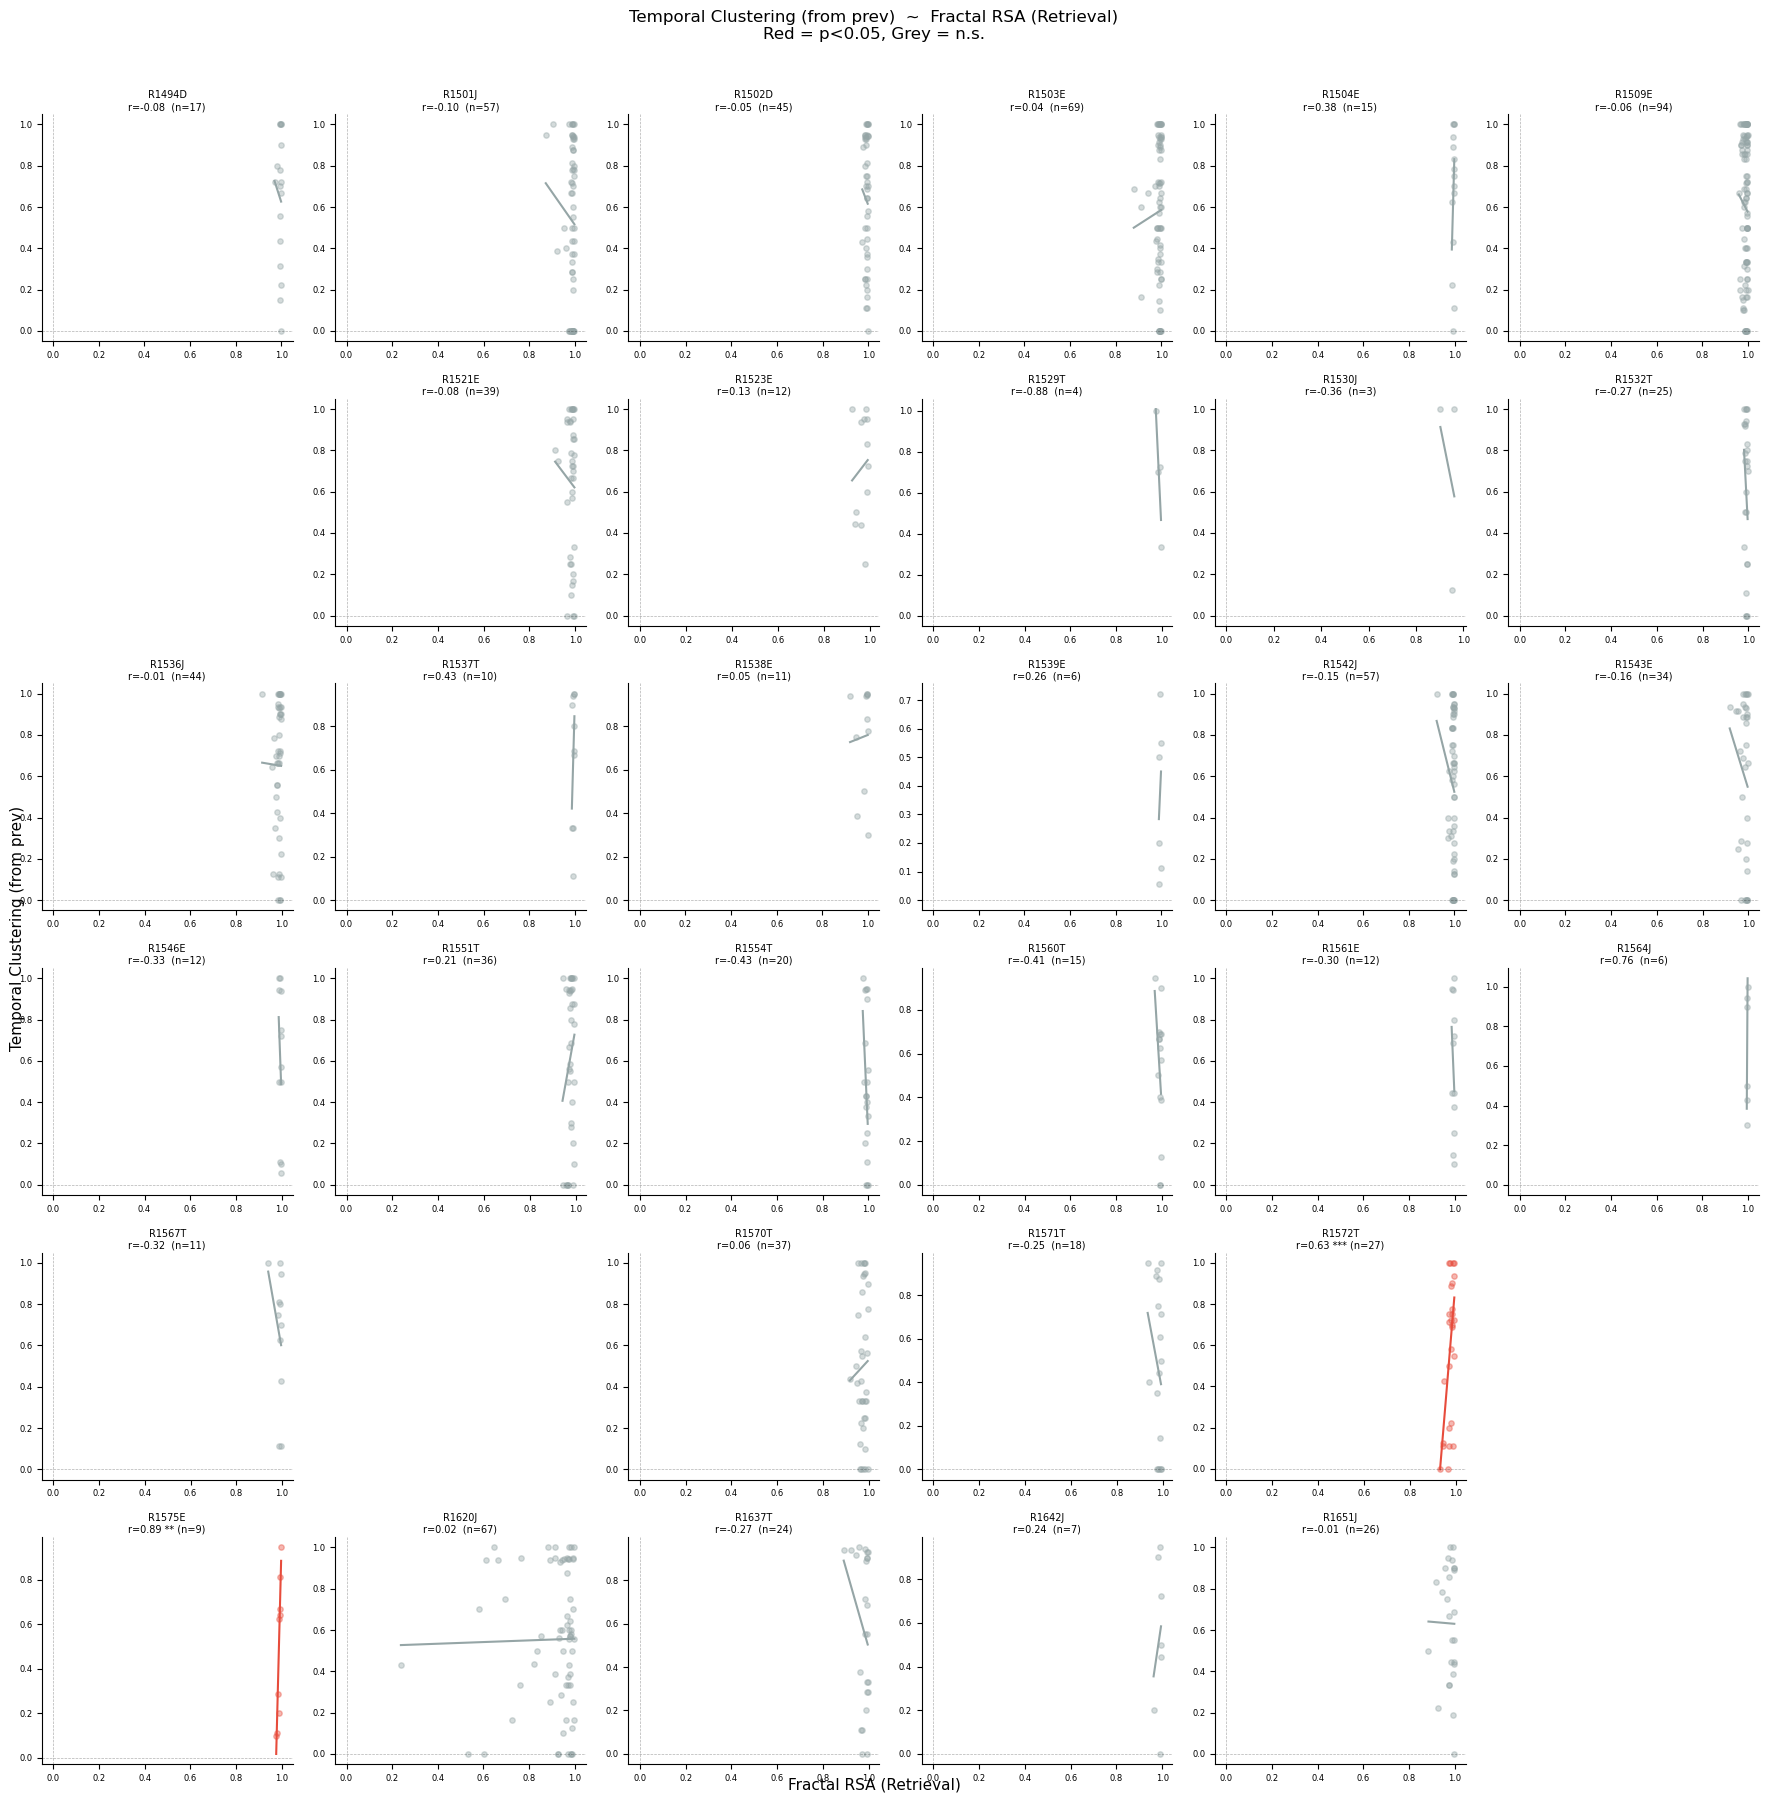

  ✓ Saved → ./rsa_scatter_plots/T_clustering_to_next__rsa_frac_retrieval.png

Plotting: T_clustering_to_next ~ rsa_osc_retrieval


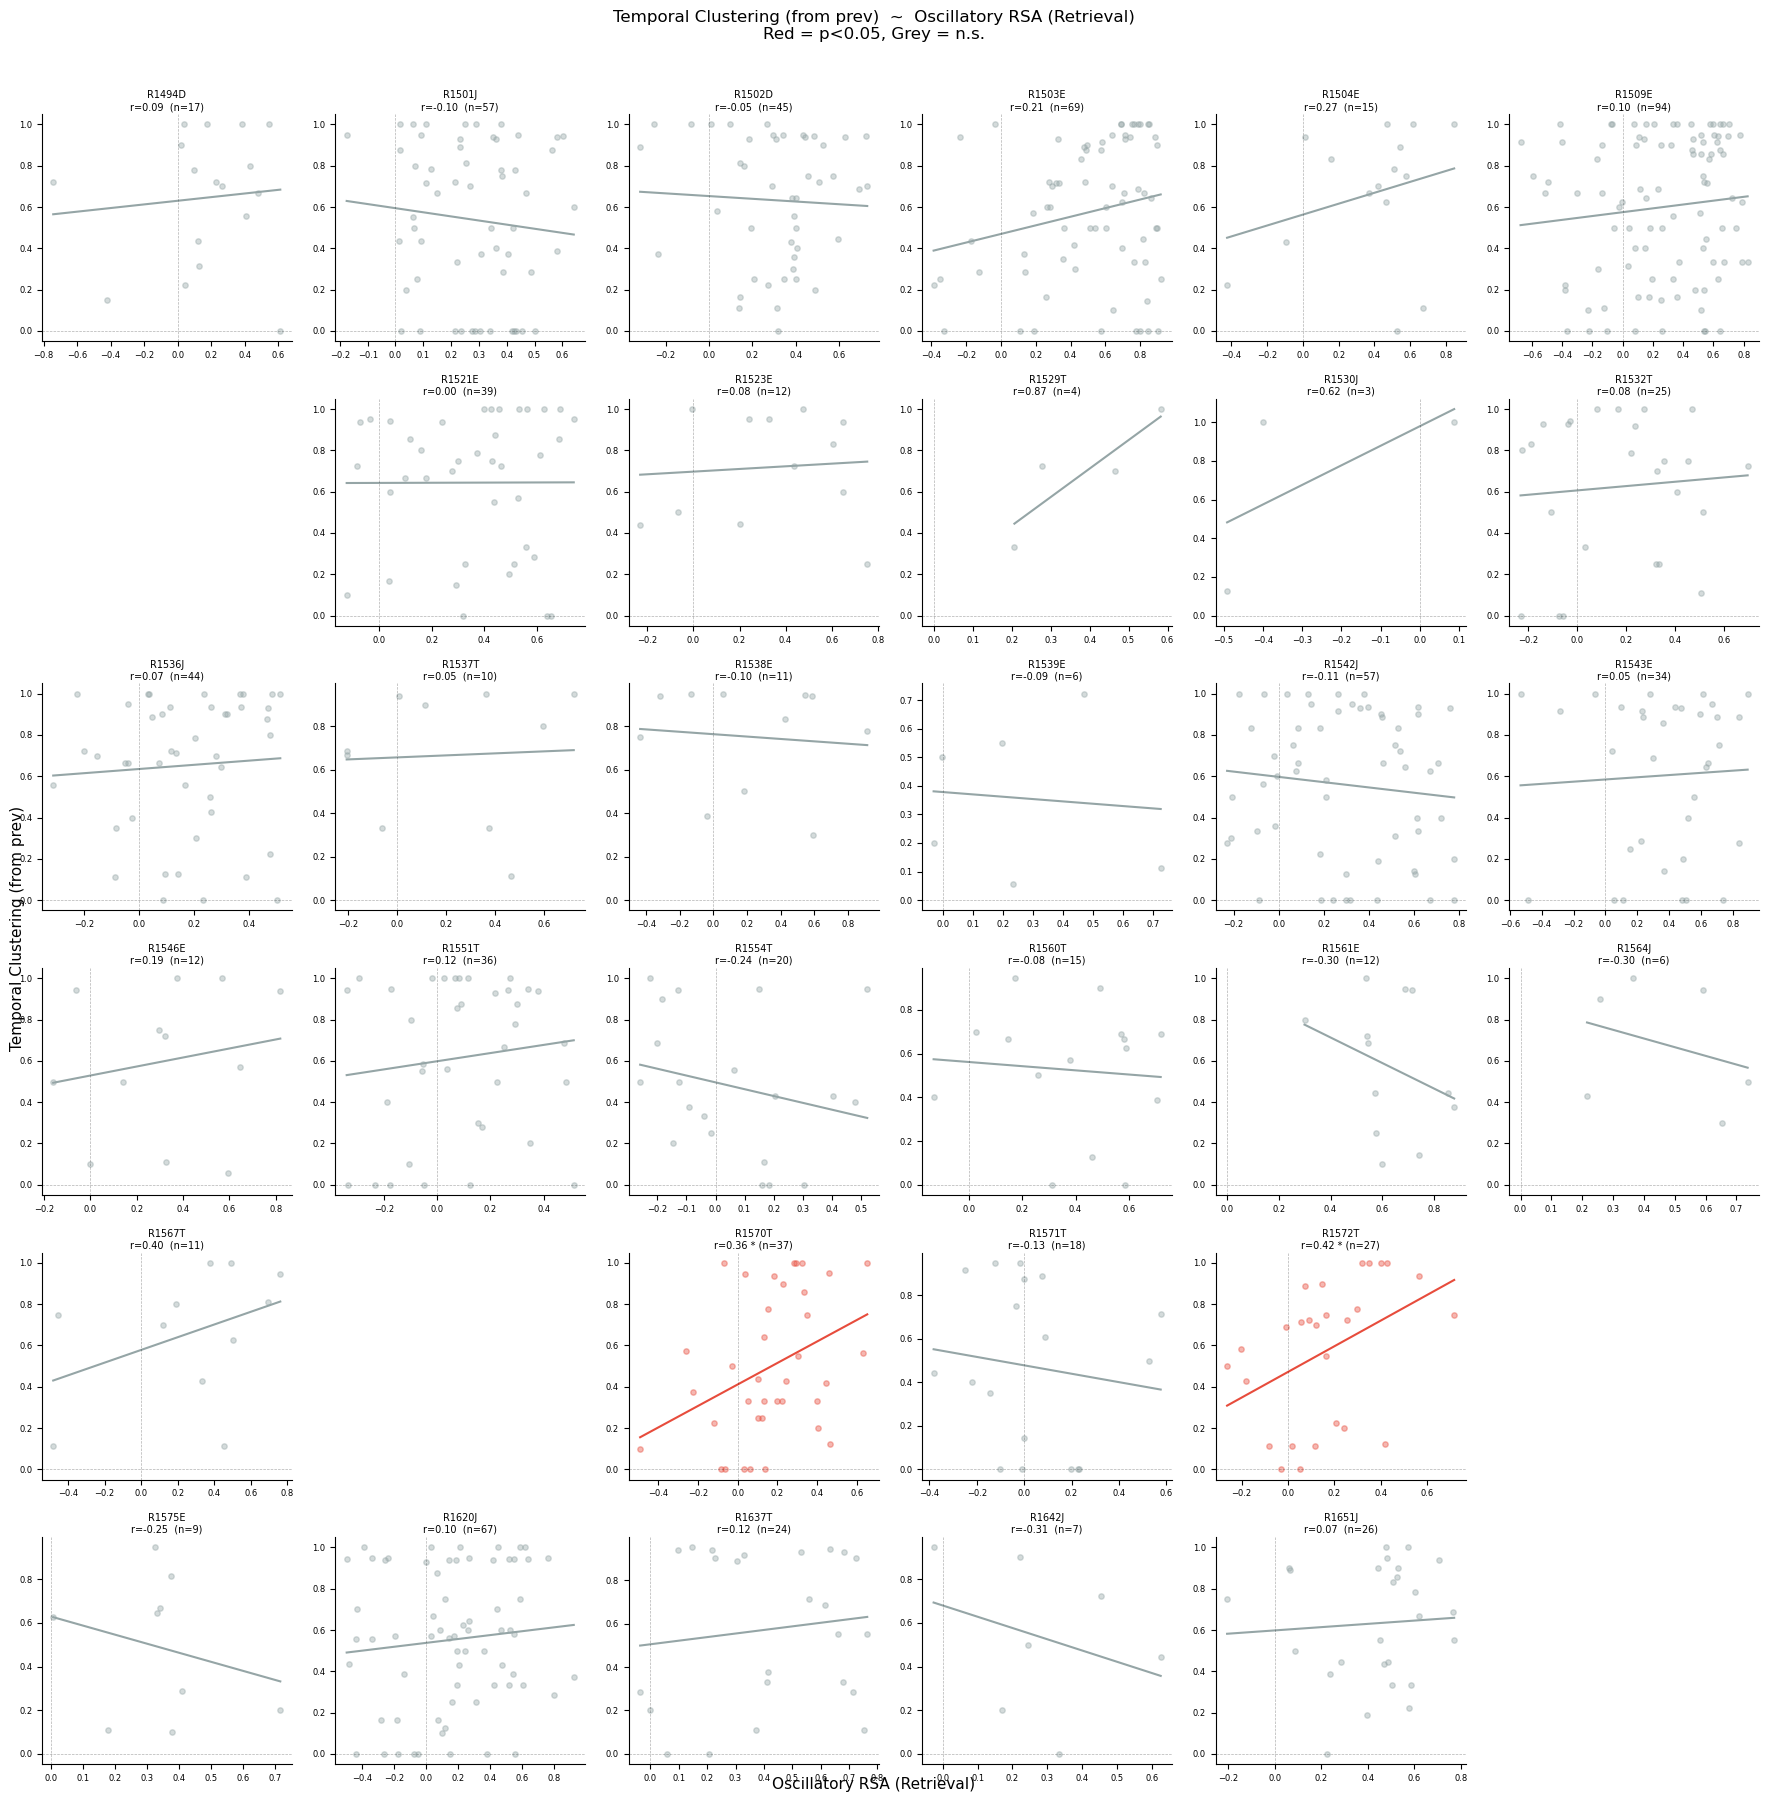

  ✓ Saved → ./rsa_scatter_plots/T_clustering_to_next__rsa_osc_retrieval.png

Plotting: T_clustering_to_next ~ rsa_frac_encoding


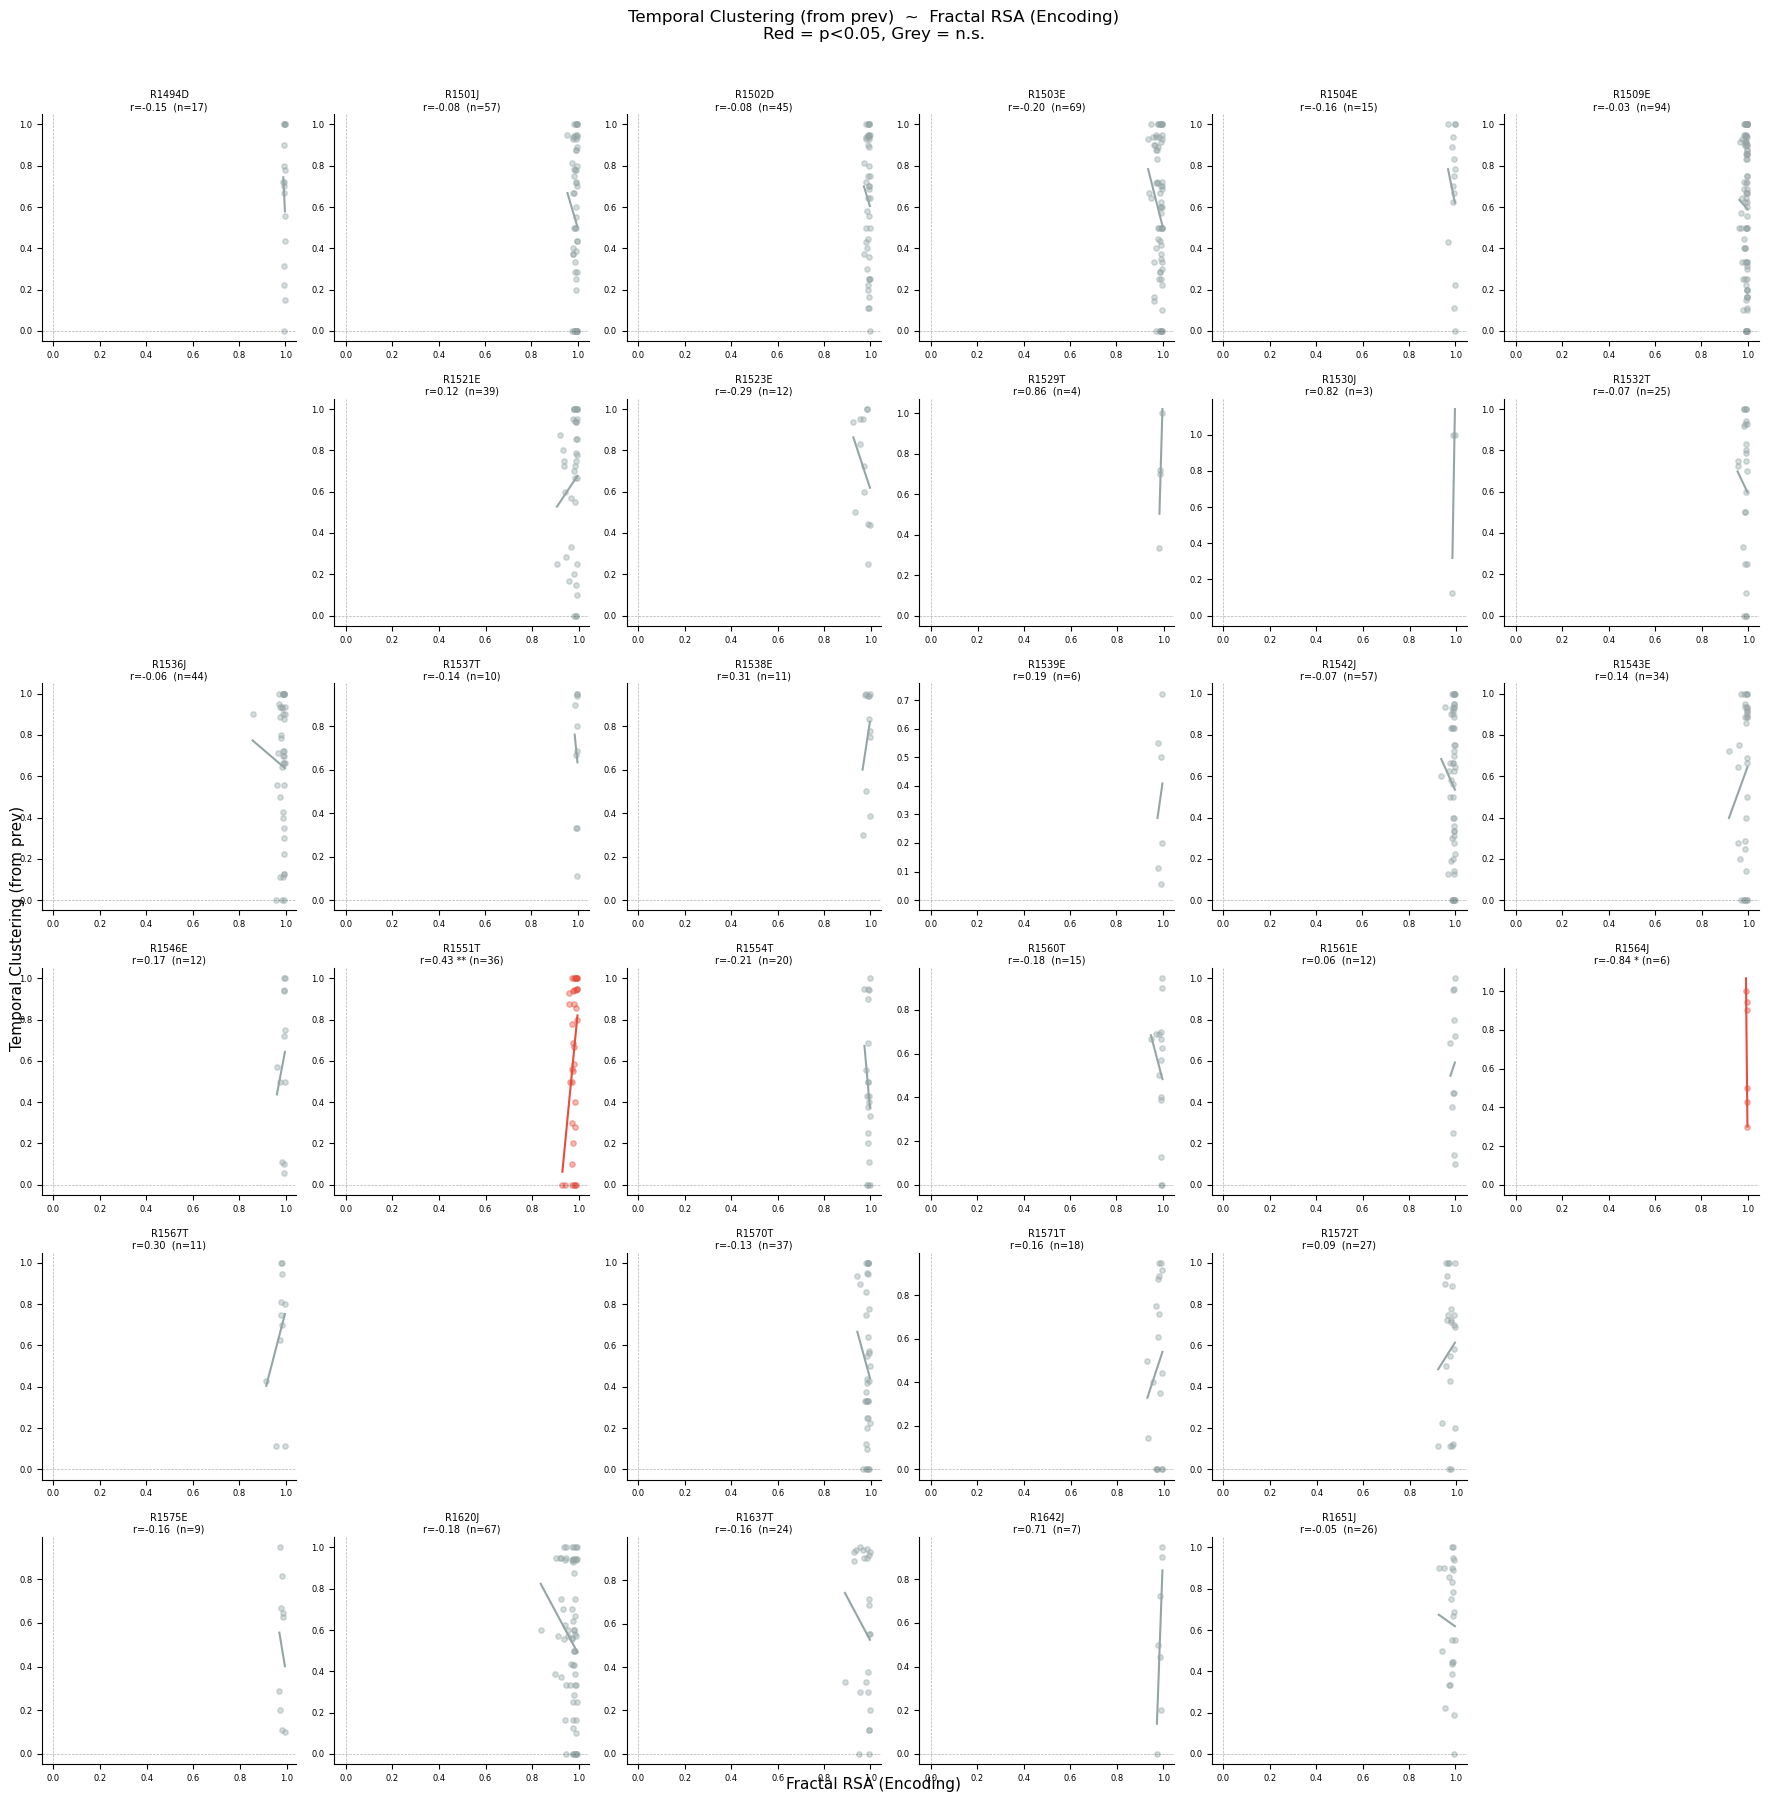

  ✓ Saved → ./rsa_scatter_plots/T_clustering_to_next__rsa_frac_encoding.png

Plotting: T_clustering_to_next ~ rsa_osc_encoding


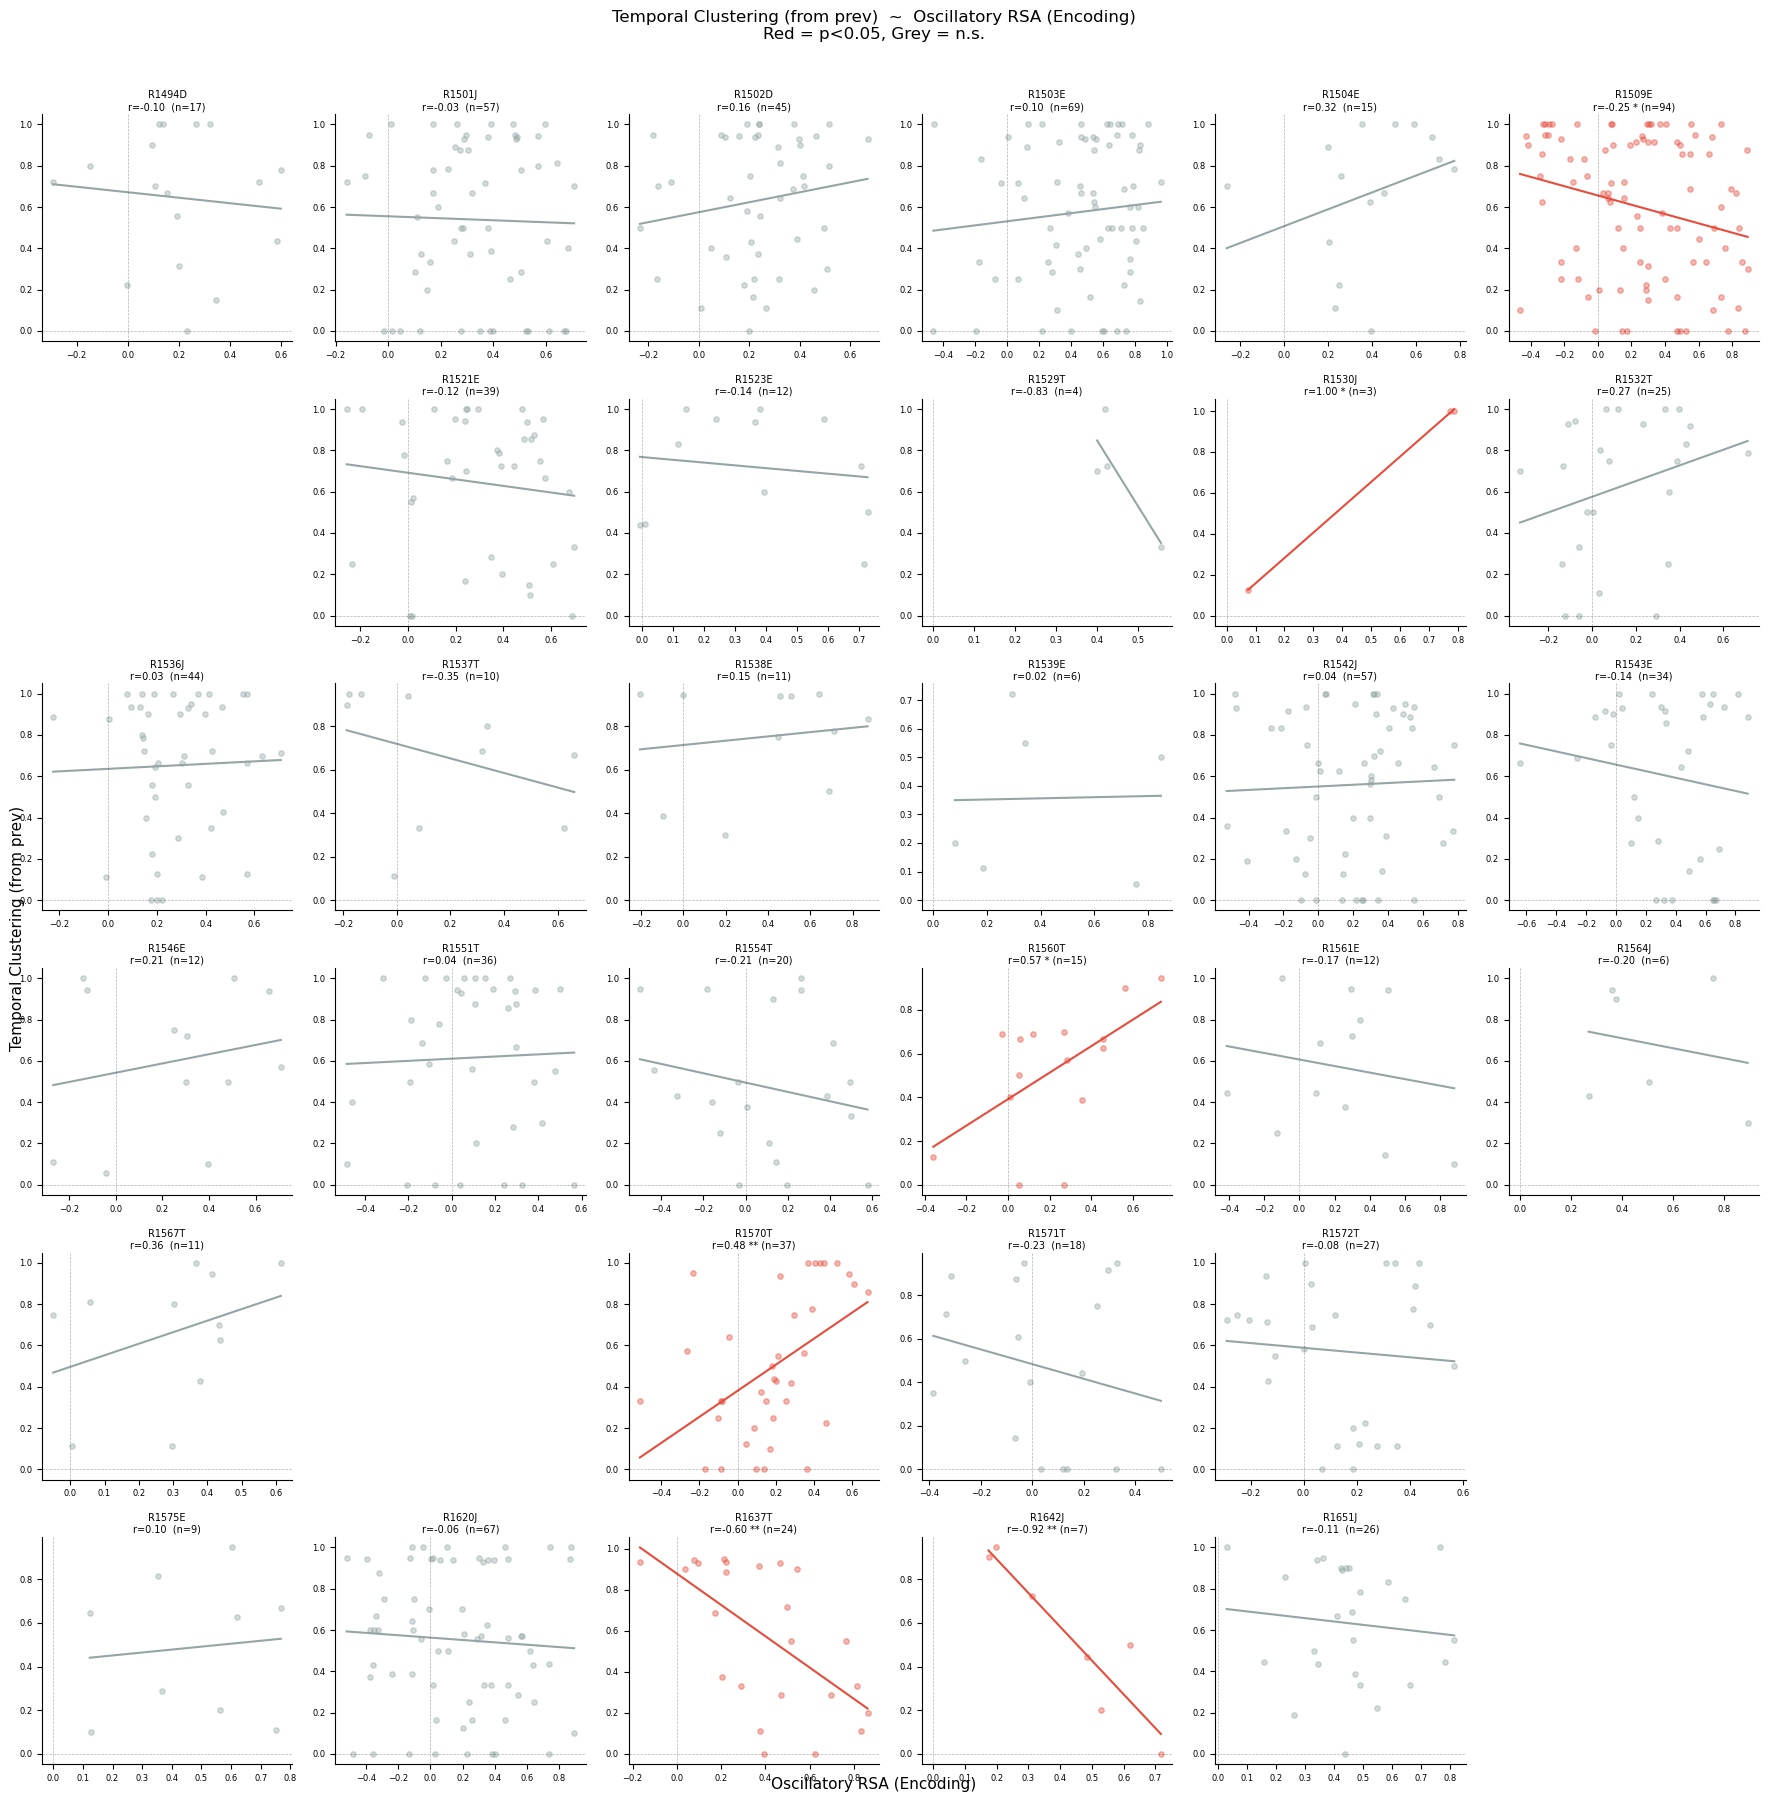

  ✓ Saved → ./rsa_scatter_plots/T_clustering_to_next__rsa_osc_encoding.png

Plotting: SP_clustering_to_next ~ rsa_frac_retrieval


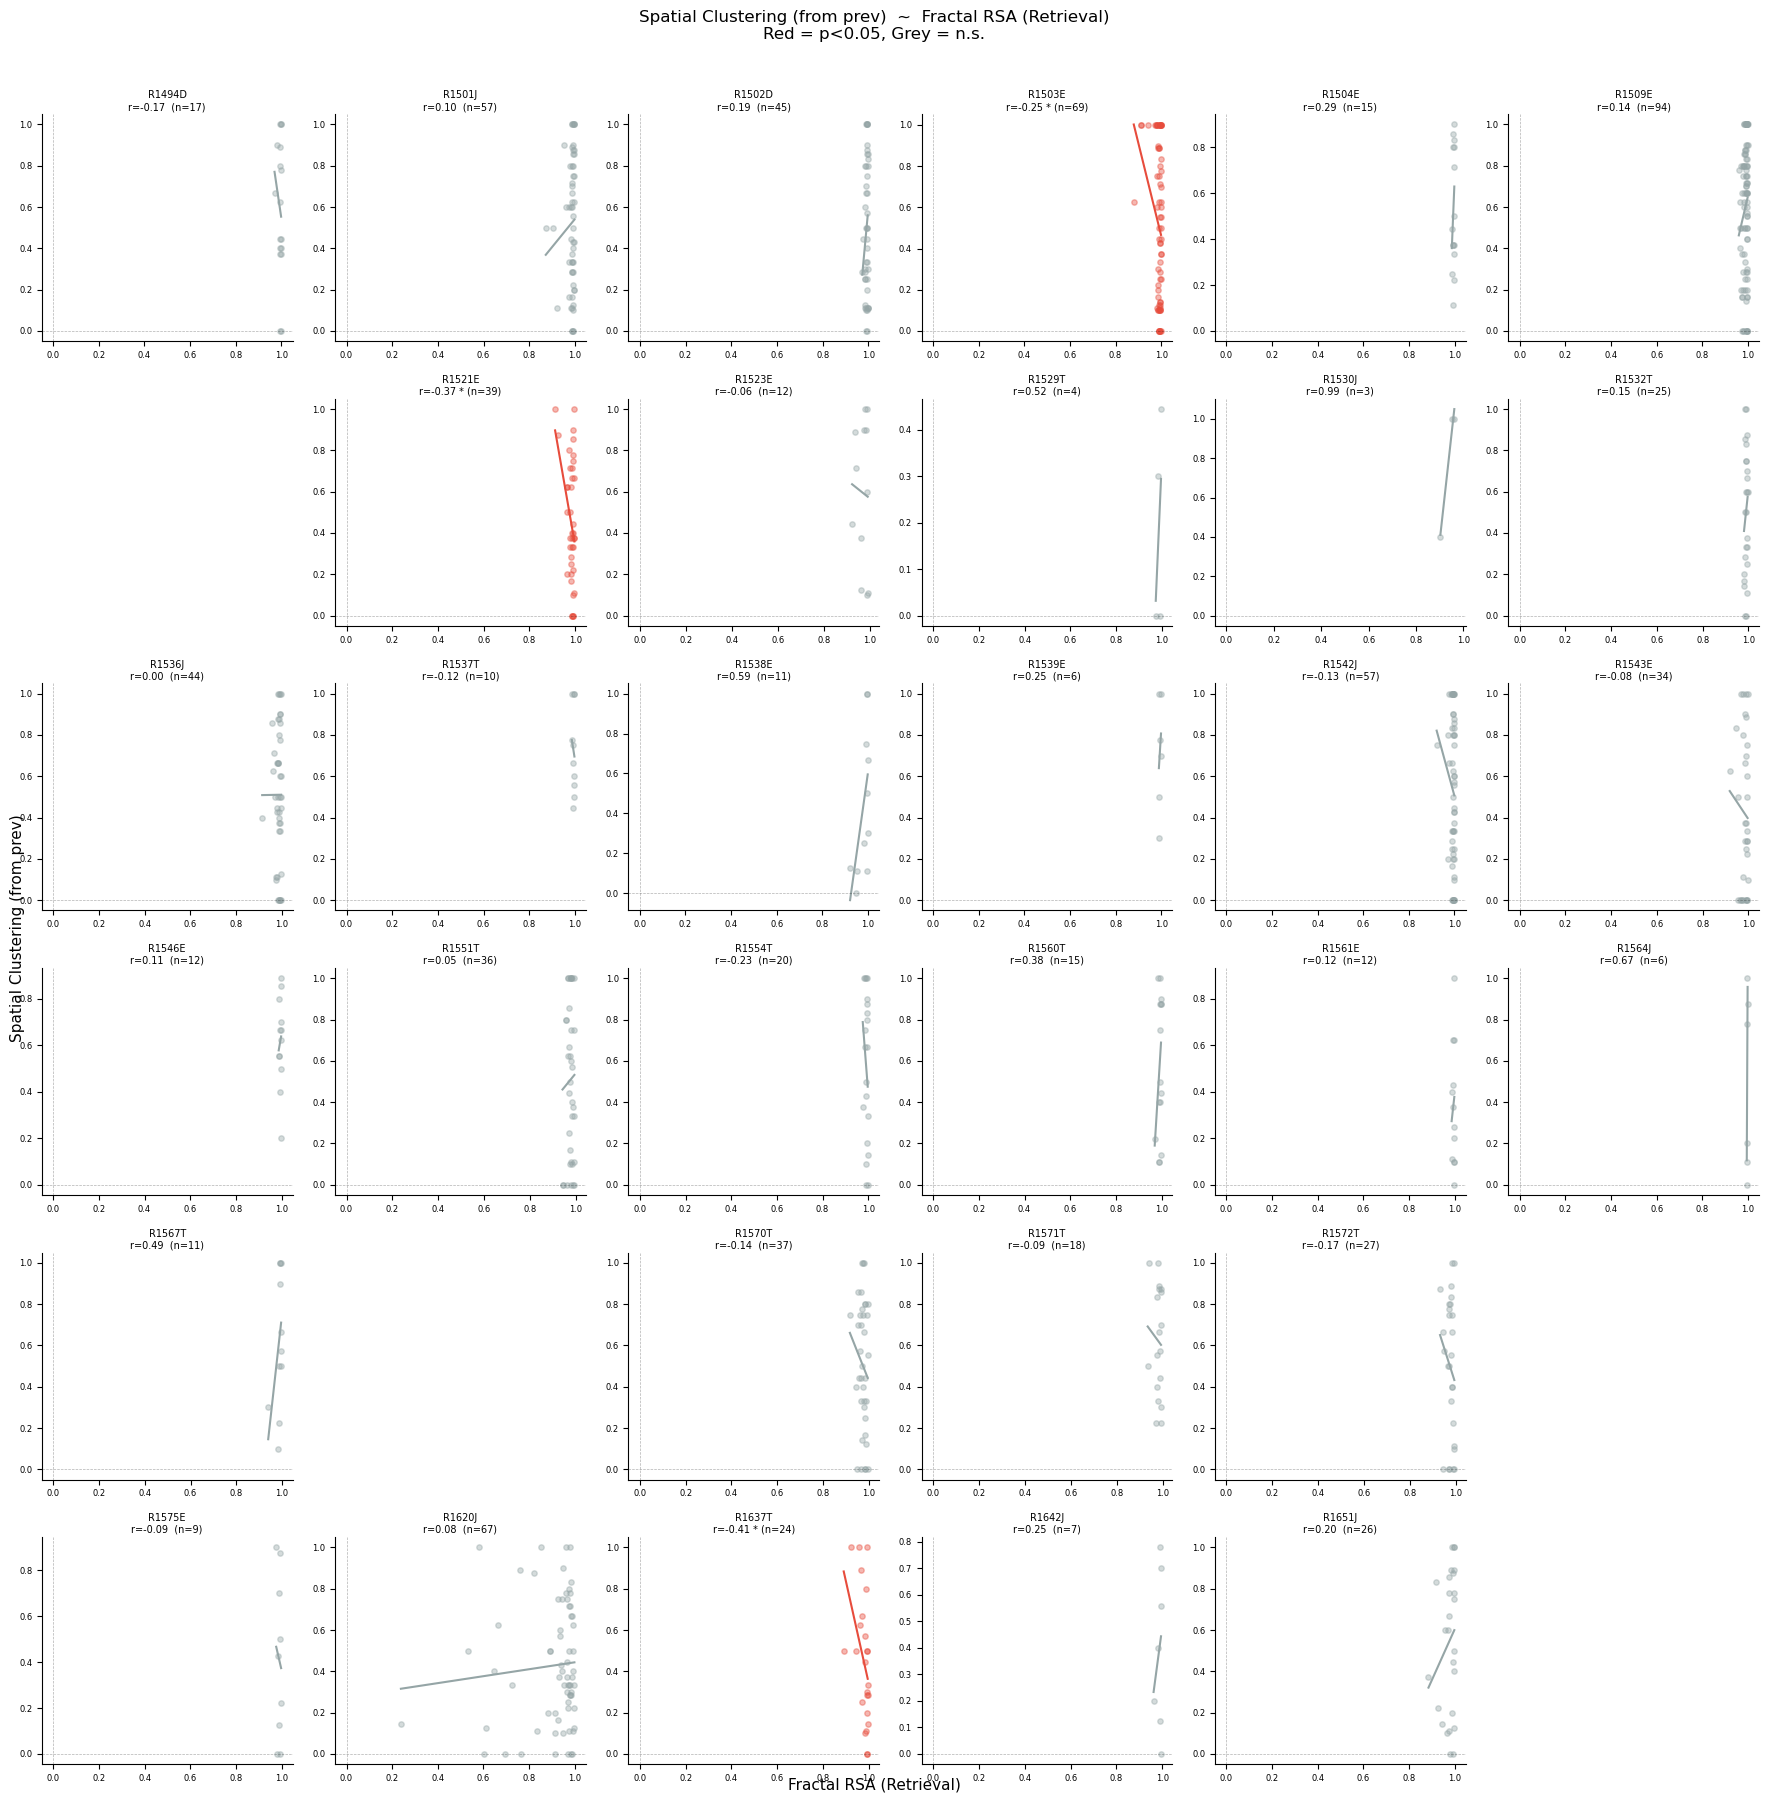

  ✓ Saved → ./rsa_scatter_plots/SP_clustering_to_next__rsa_frac_retrieval.png

Plotting: SP_clustering_to_next ~ rsa_osc_retrieval


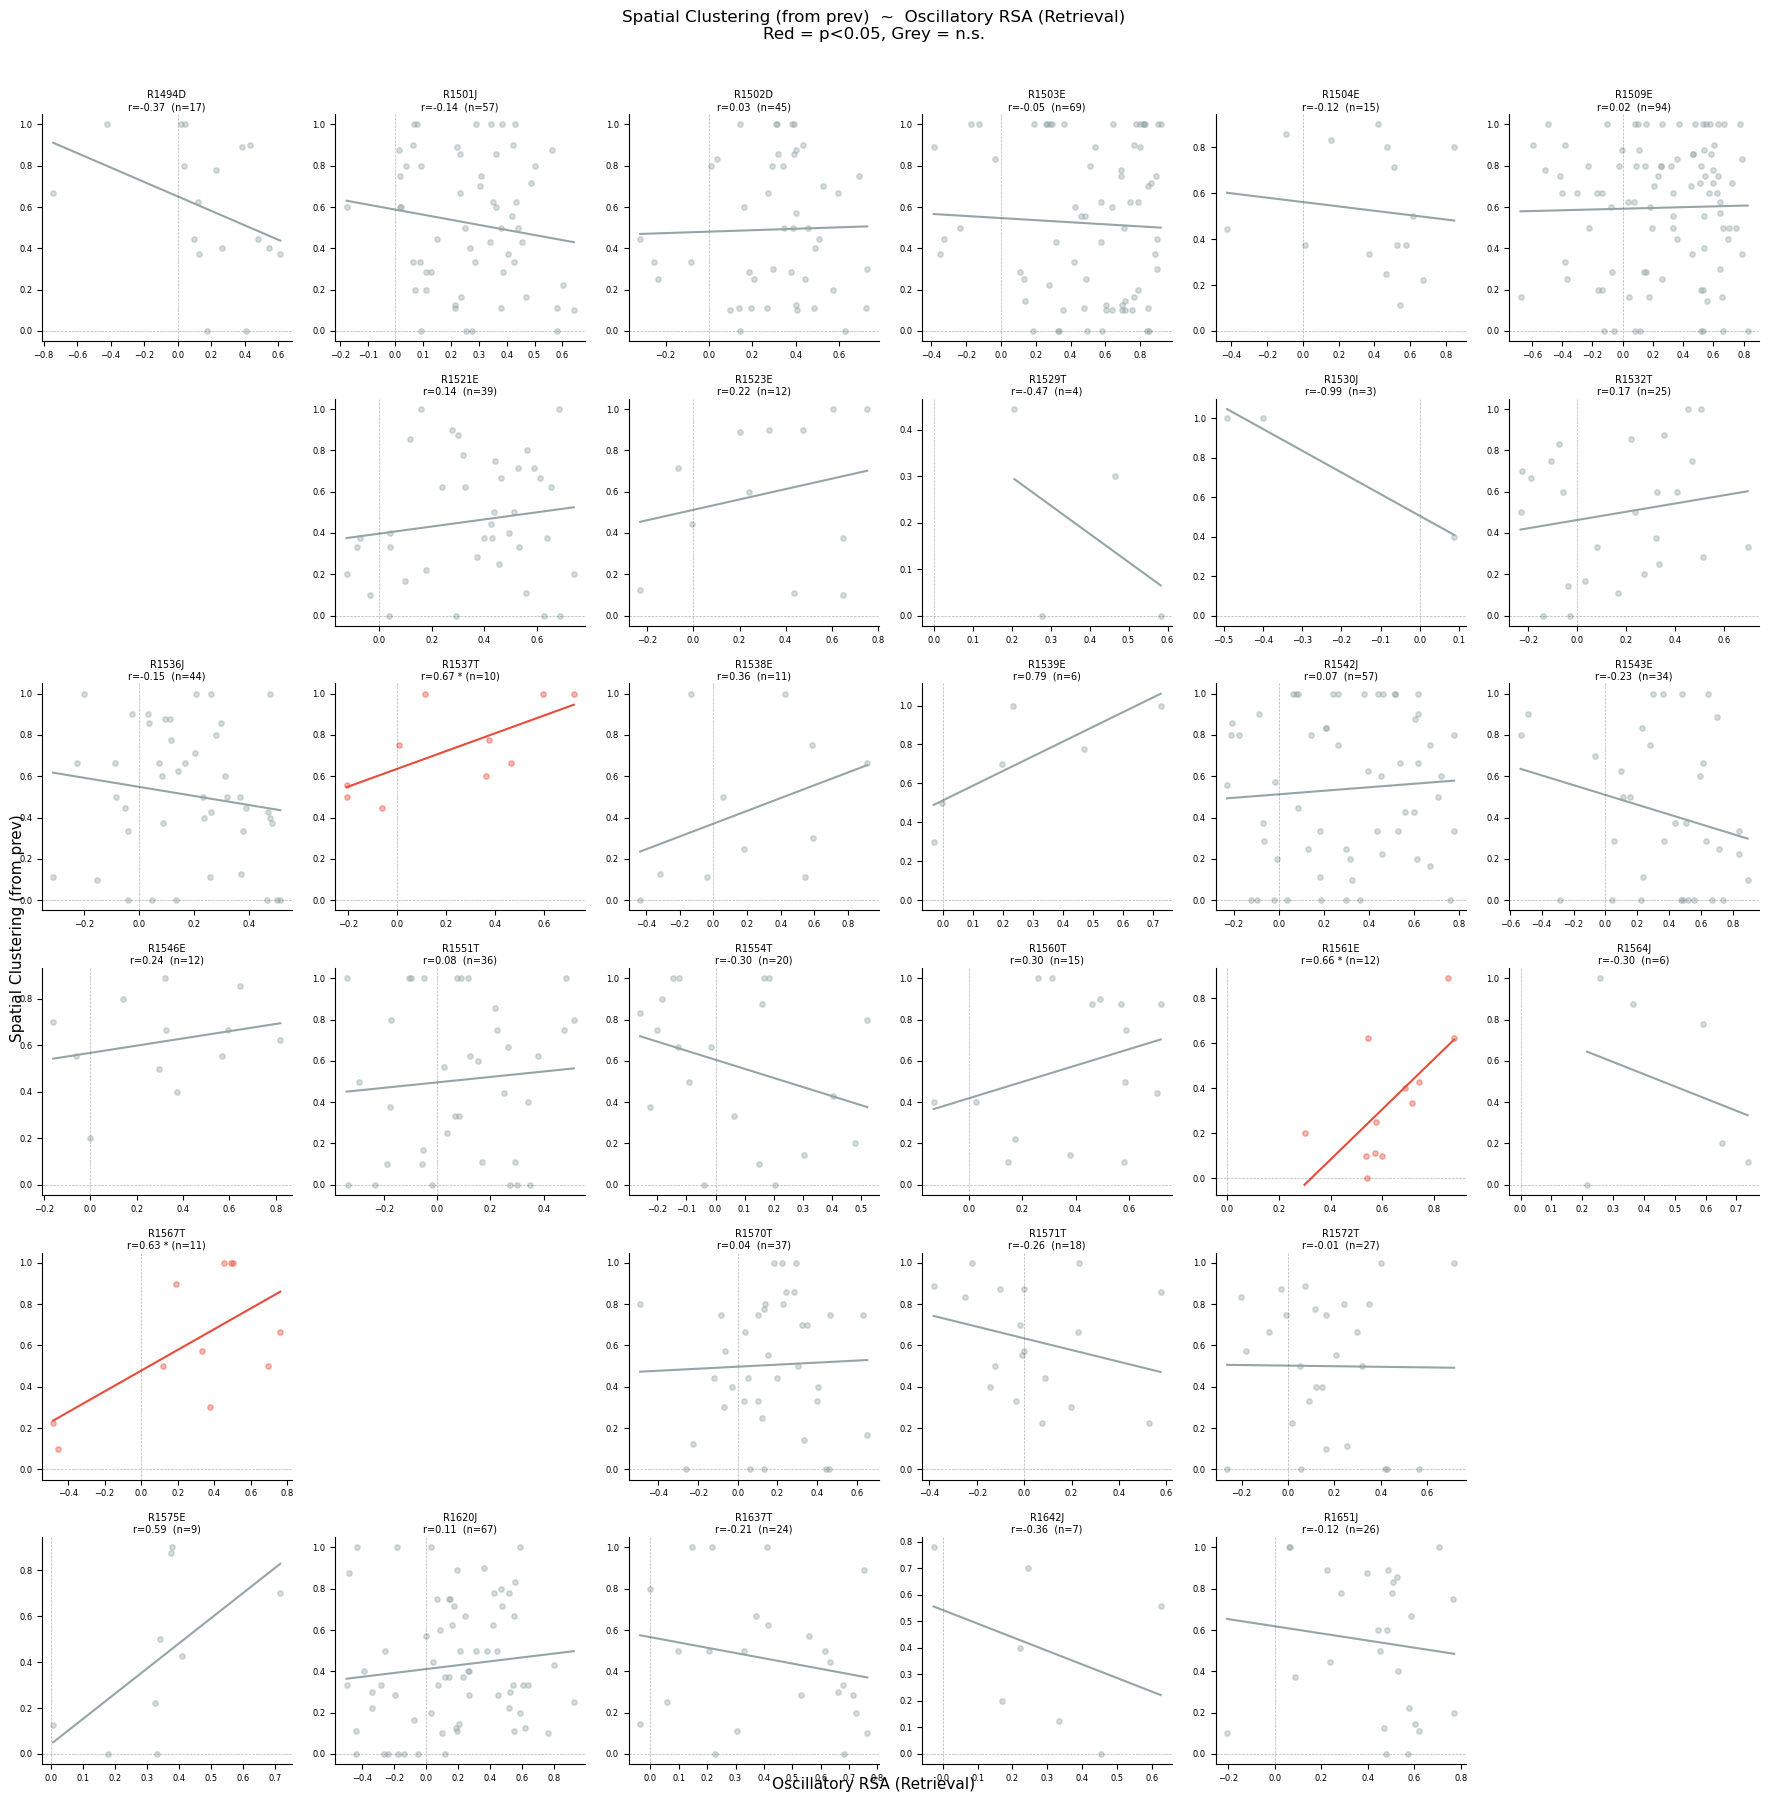

  ✓ Saved → ./rsa_scatter_plots/SP_clustering_to_next__rsa_osc_retrieval.png

Plotting: SP_clustering_to_next ~ rsa_frac_encoding


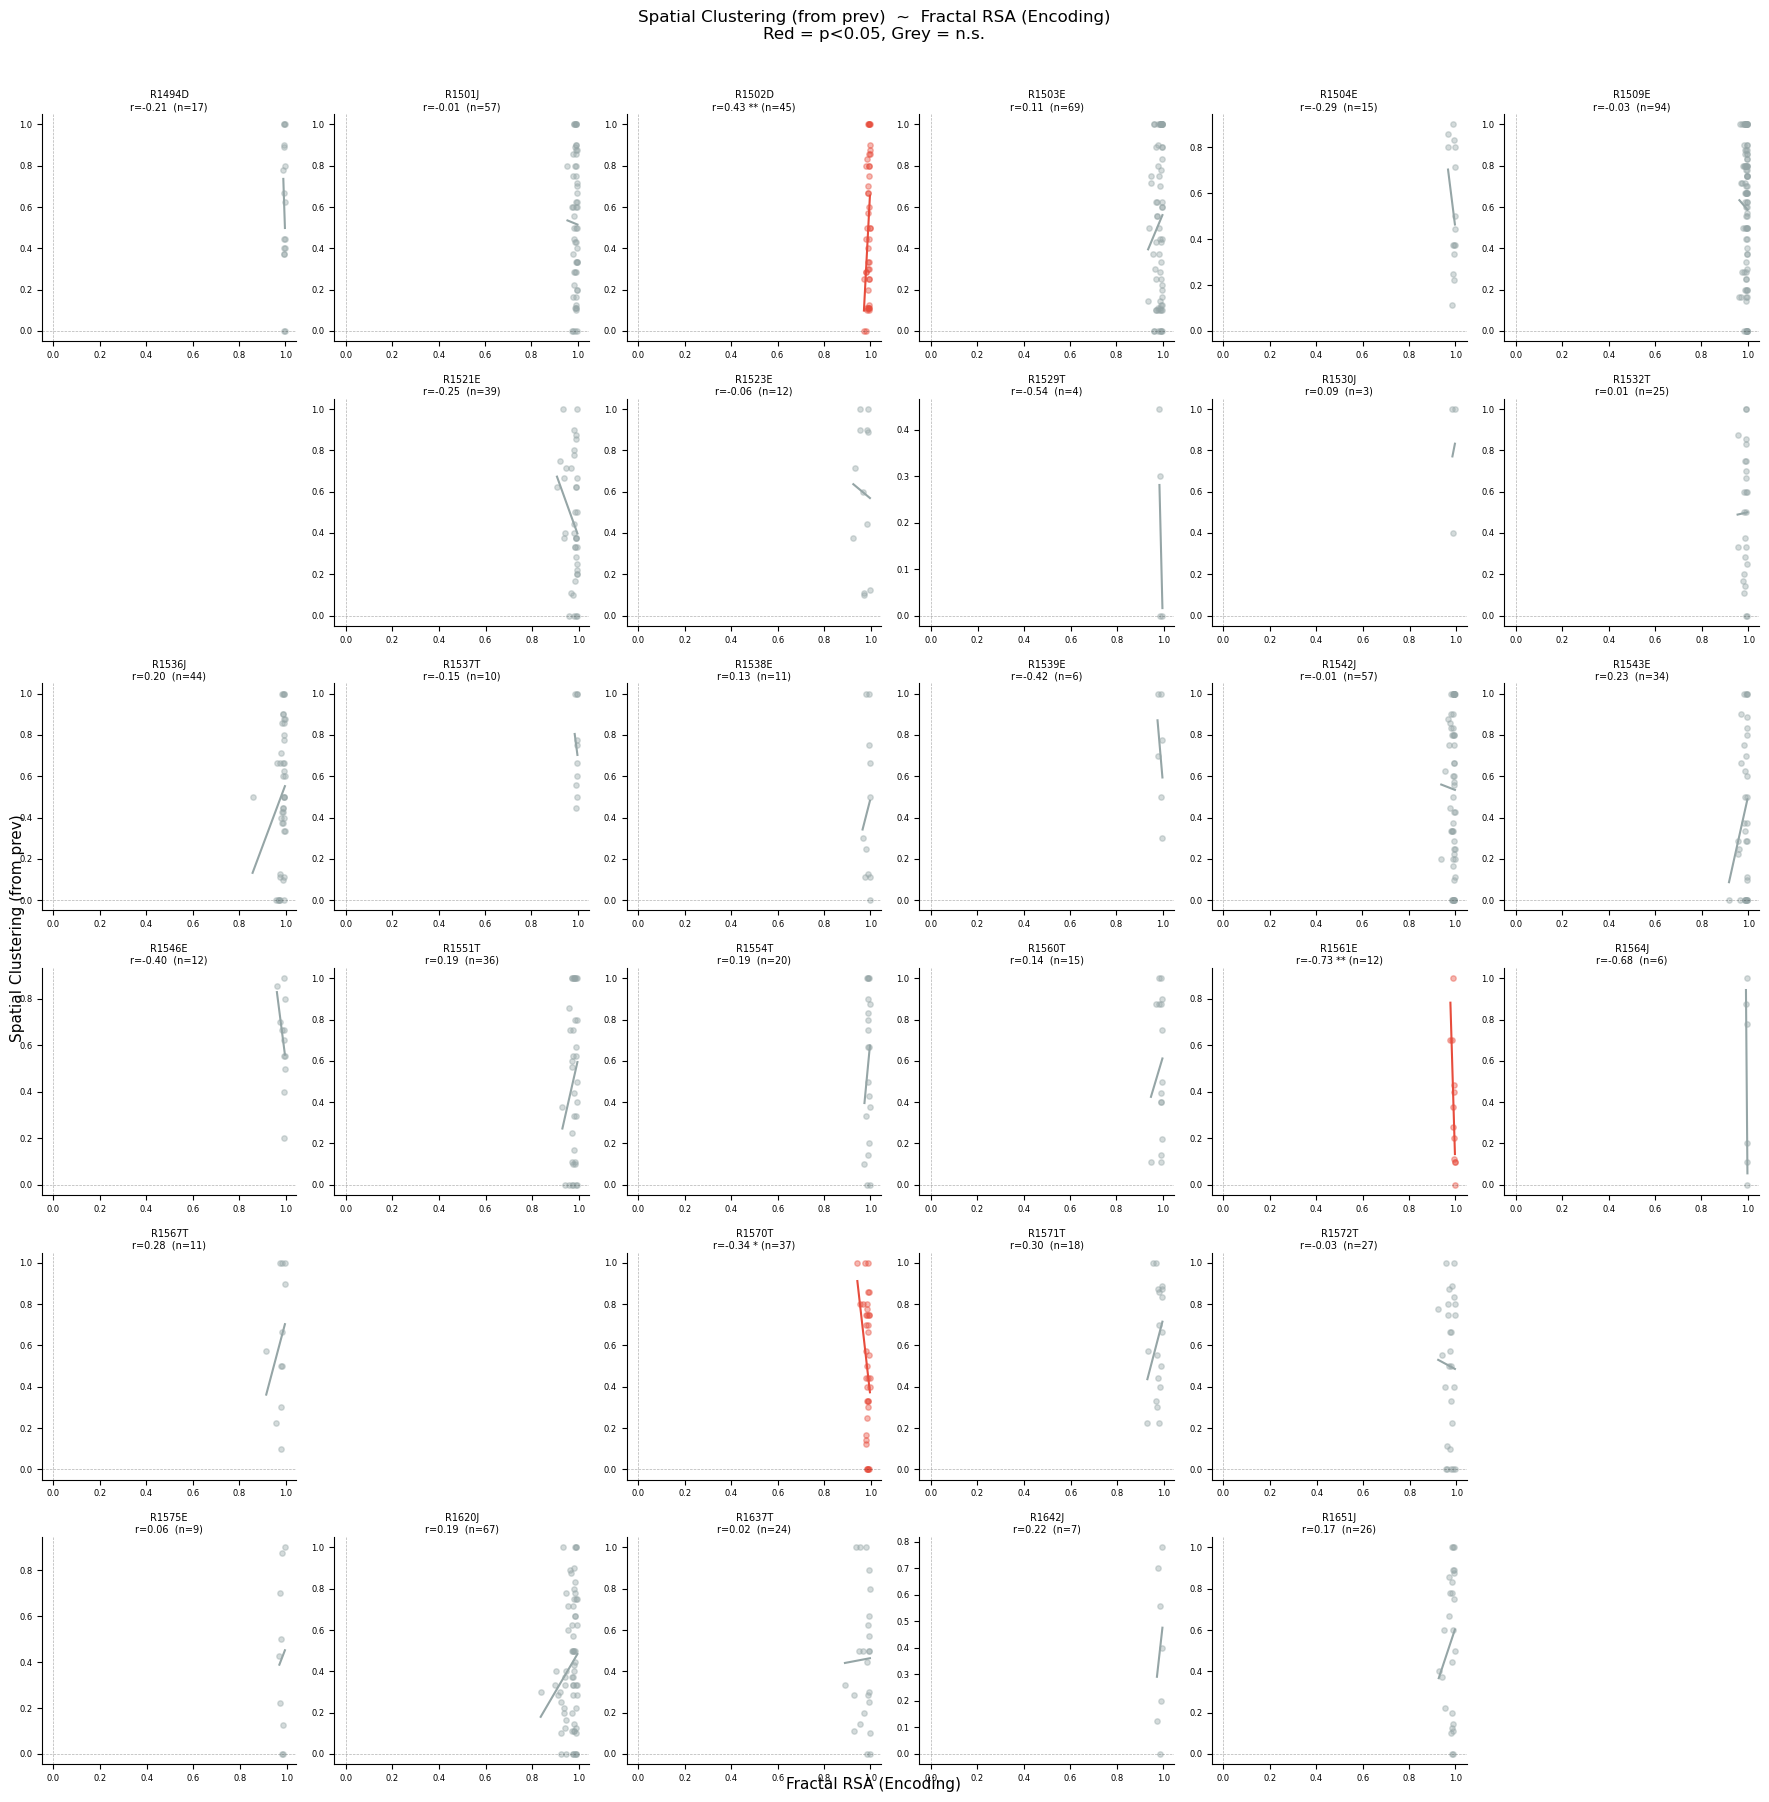

  ✓ Saved → ./rsa_scatter_plots/SP_clustering_to_next__rsa_frac_encoding.png

Plotting: SP_clustering_to_next ~ rsa_osc_encoding


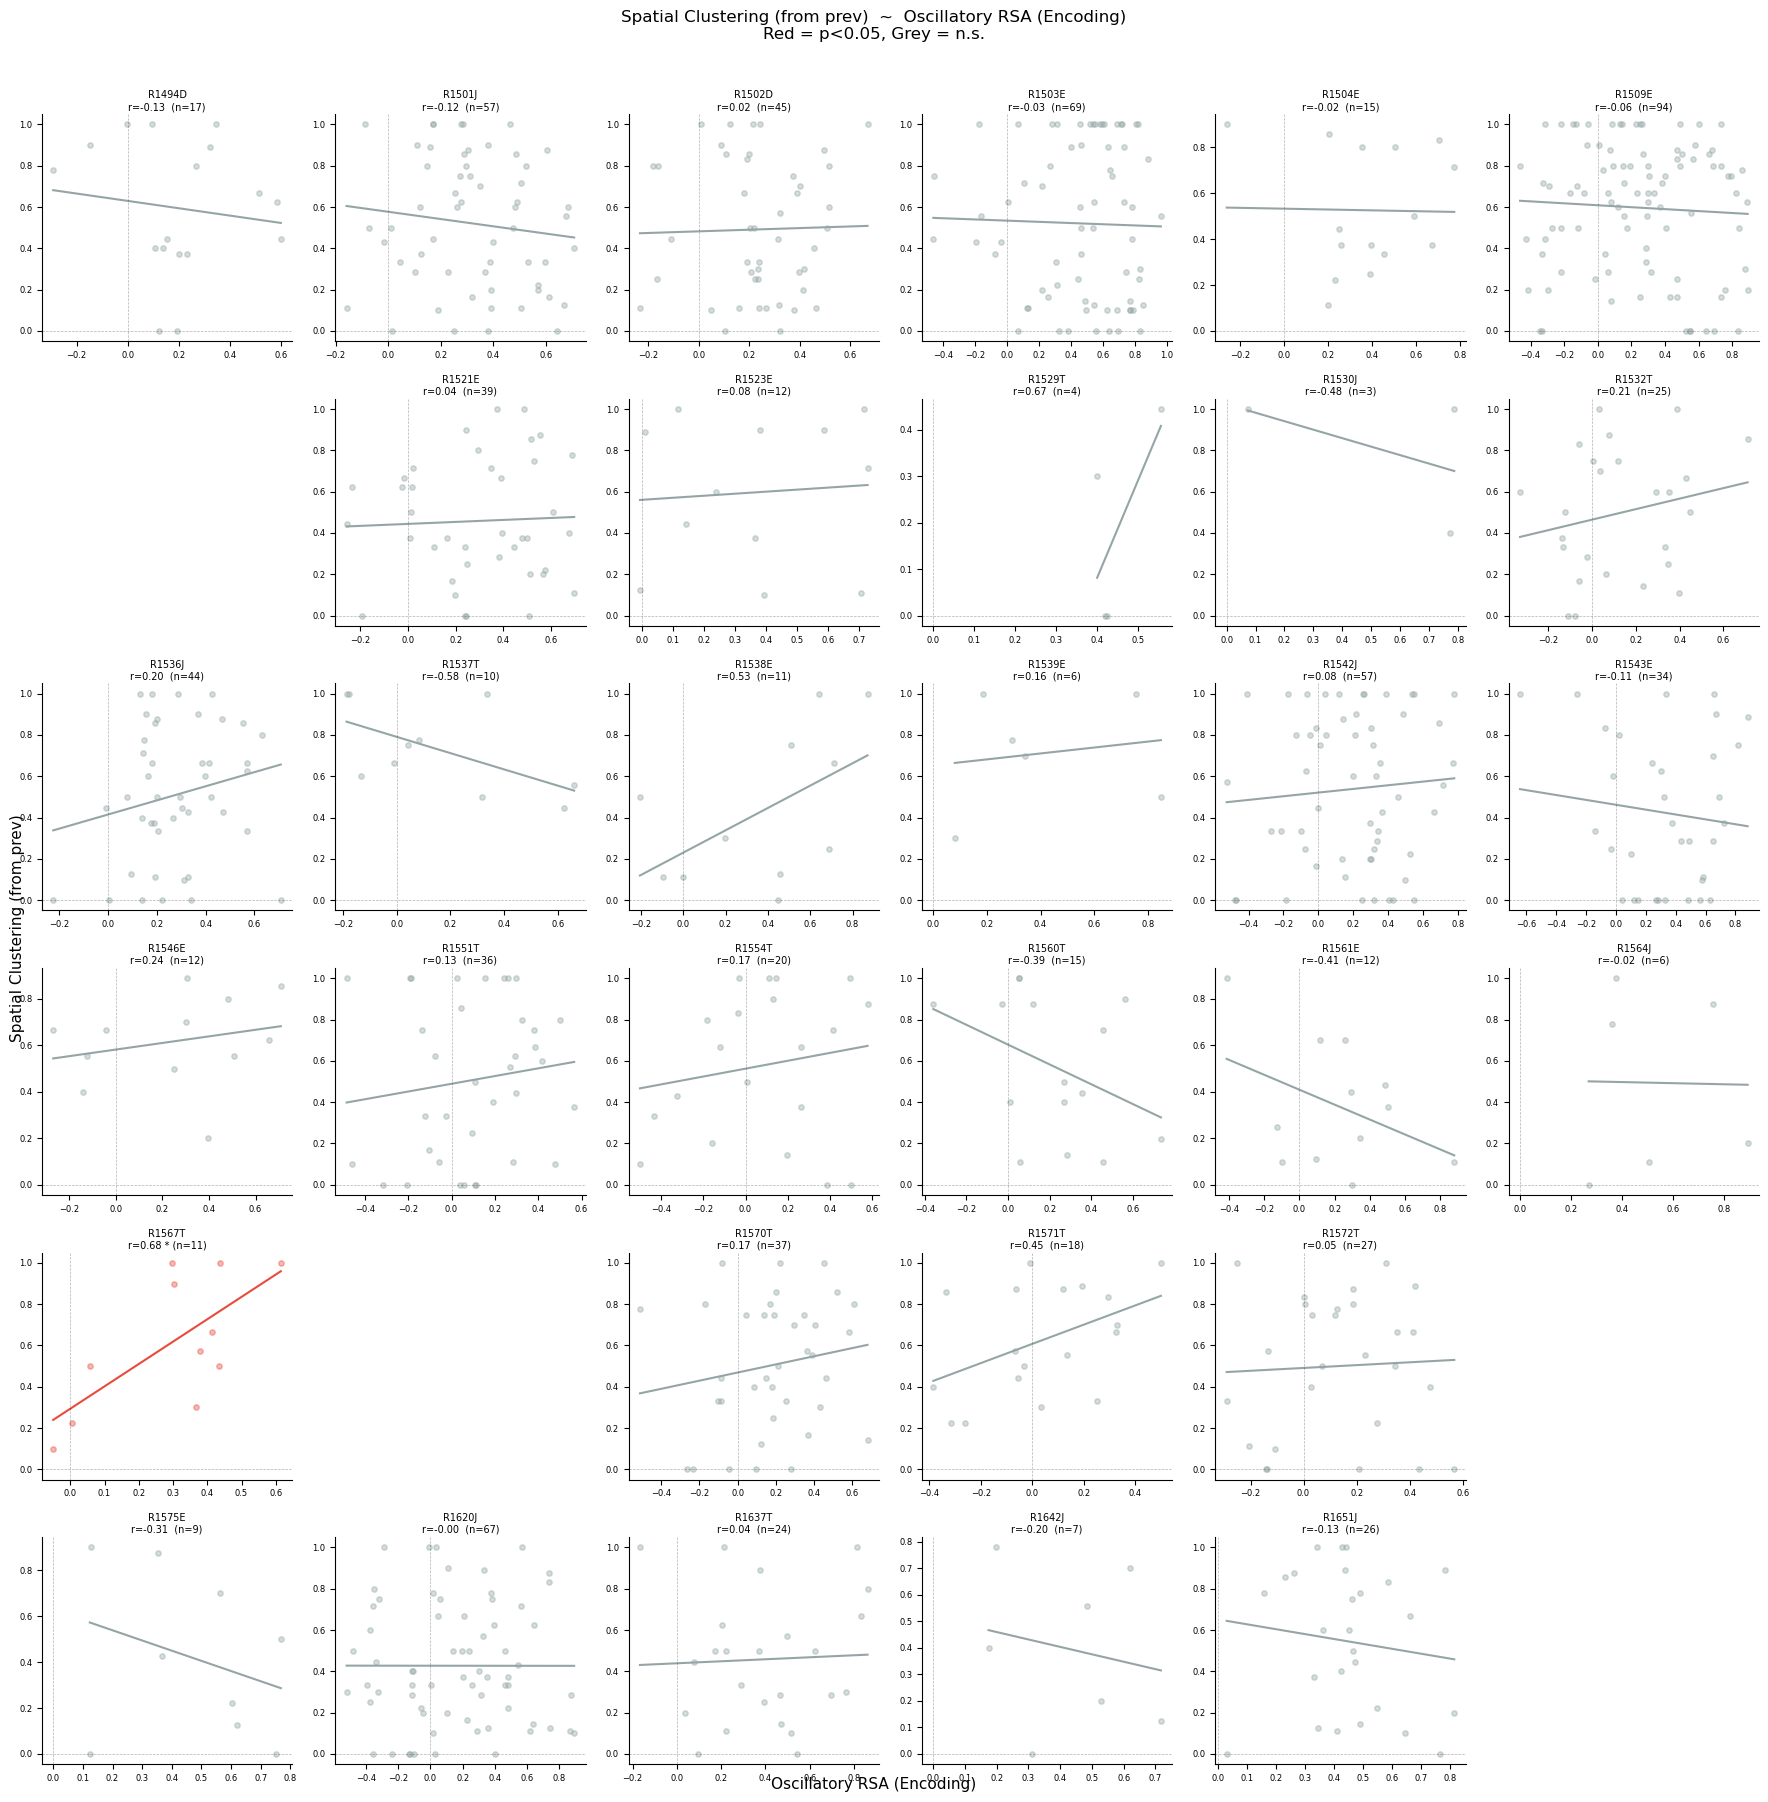

  ✓ Saved → ./rsa_scatter_plots/SP_clustering_to_next__rsa_osc_encoding.png

Generating group-level r summary panel ...


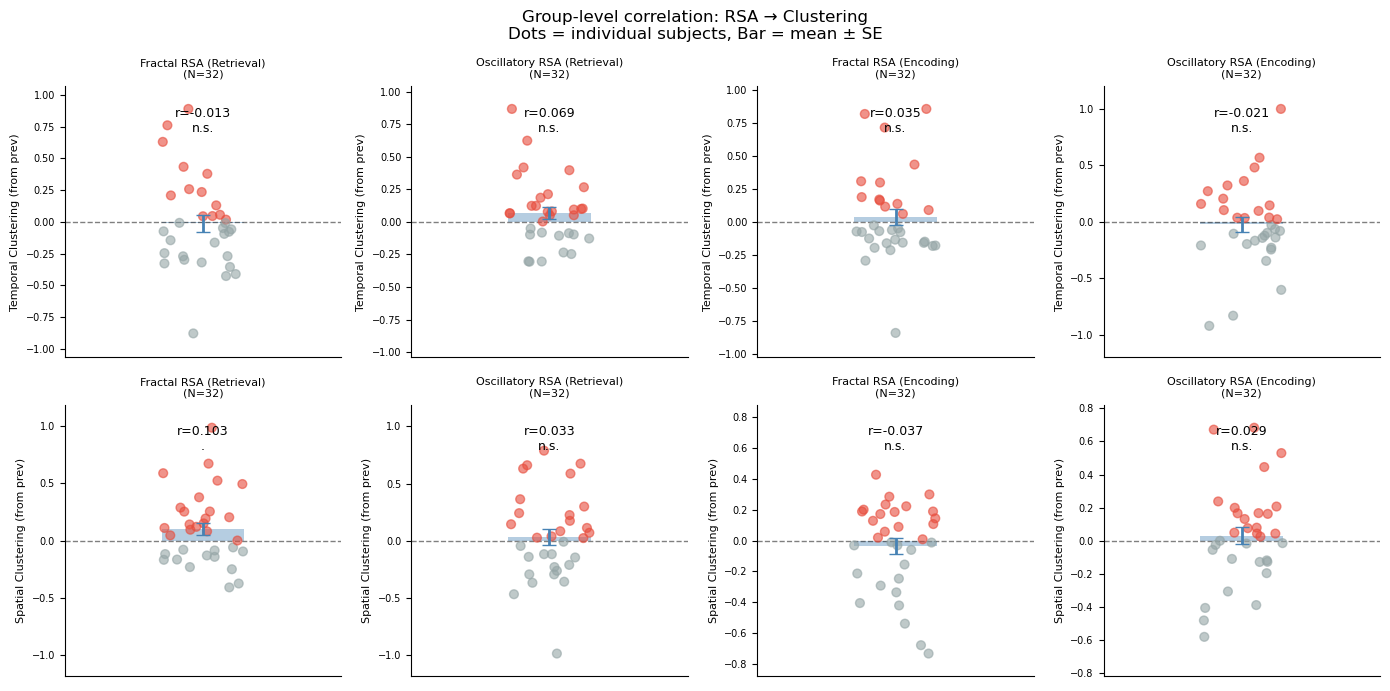

✓ Group summary panel saved → ./rsa_scatter_plots/group_summary_panel.png

All plots saved to: ./rsa_scatter_plots/


In [28]:
"""
Visualization: Correlation scatter per subject
-----------------------------------------------
For each outcome × predictor combination, plot one scatter per subject
showing RSA value vs clustering score with regression line.

Input : ALL_SUBJECTS_word_level_rsa.csv
Output: scatter plots saved as PNG files
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa.csv'
OUTPUT_DIR = './rsa_scatter_plots'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTCOMES = [
    'T_clustering_to_next',
    'SP_clustering_to_next',
]

PREDICTORS = [
    'rsa_frac_retrieval',
    'rsa_osc_retrieval',
    'rsa_frac_encoding',
    'rsa_osc_encoding',
]

PREDICTOR_LABELS = {
    'rsa_frac_retrieval': 'Fractal RSA (Retrieval)',
    'rsa_osc_retrieval' : 'Oscillatory RSA (Retrieval)',
    'rsa_frac_encoding' : 'Fractal RSA (Encoding)',
    'rsa_osc_encoding'  : 'Oscillatory RSA (Encoding)',
}

OUTCOME_LABELS = {
    'T_clustering_to_next' : 'Temporal Clustering (to next)',
    'SP_clustering_to_next': 'Spatial Clustering (to next)',
}

# Color for significant vs non-significant subjects
COLOR_SIG   = '#e74c3c'   # red — significant correlation
COLOR_NSIG  = '#95a5a6'   # grey — non-significant
ALPHA_DOT   = 0.4
DOT_SIZE    = 15

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

subjects = sorted(df['subject'].unique())
n_subj   = len(subjects)

# ============================================================================
# PLOT — one figure per outcome × predictor
# ============================================================================

for outcome in OUTCOMES:
    for pred in PREDICTORS:

        print(f"\nPlotting: {outcome} ~ {pred}")

        # Determine grid size
        n_cols = 6
        n_rows = int(np.ceil(n_subj / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(n_cols * 3, n_rows * 3),
            squeeze=False
        )

        for s_idx, subject in enumerate(subjects):
            ax  = axes[s_idx // n_cols][s_idx % n_cols]
            sub = df[df['subject'] == subject][[outcome, pred]].dropna()

            if len(sub) < 3:
                ax.set_visible(False)
                continue

            x = sub[pred].values
            y = sub[outcome].values

            # Pearson correlation
            r, p = stats.pearsonr(x, y)

            # Regression line
            slope, intercept, _, _, _ = stats.linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = slope * x_line + intercept

            # Color by significance
            color = COLOR_SIG if p < 0.05 else COLOR_NSIG

            ax.scatter(x, y, s=DOT_SIZE, alpha=ALPHA_DOT, color=color)
            ax.plot(x_line, y_line, color=color, linewidth=1.5)

            # Significance stars
            if   p < 0.001: stars = '***'
            elif p < 0.01:  stars = '**'
            elif p < 0.05:  stars = '*'
            else:           stars = ''

            ax.set_title(
                f"{subject}\nr={r:.2f} {stars} (n={len(sub)})",
                fontsize=7,
                pad=3
            )
            ax.tick_params(labelsize=6)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Add zero lines for reference
            ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
            ax.axvline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)

        # Hide unused subplots
        for s_idx in range(n_subj, n_rows * n_cols):
            axes[s_idx // n_cols][s_idx % n_cols].set_visible(False)

        # Figure-level labels
        fig.supxlabel(PREDICTOR_LABELS[pred], fontsize=11, y=0.02)
        fig.supylabel(OUTCOME_LABELS[outcome], fontsize=11, x=0.02)
        fig.suptitle(
            f"{OUTCOME_LABELS[outcome]}  ~  {PREDICTOR_LABELS[pred]}\n"
            f"Red = p<0.05, Grey = n.s.",
            fontsize=12,
            y=1.01
        )

        plt.tight_layout()

        fname = f"{outcome}__{pred}.png"
        fpath = os.path.join(OUTPUT_DIR, fname)
        fig.savefig(fpath, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"  ✓ Saved → {fpath}")

# ============================================================================
# SUMMARY PANEL — group-level r values across subjects
# ============================================================================

print("\nGenerating group-level r summary panel ...")

fig, axes = plt.subplots(
    len(OUTCOMES), len(PREDICTORS),
    figsize=(len(PREDICTORS) * 3.5, len(OUTCOMES) * 3.5),
    squeeze=False
)

for o_idx, outcome in enumerate(OUTCOMES):
    for p_idx, pred in enumerate(PREDICTORS):
        ax = axes[o_idx][p_idx]

        r_values = []
        for subject in subjects:
            sub = df[df['subject'] == subject][[outcome, pred]].dropna()
            if len(sub) < 3:
                continue
            r, _ = stats.pearsonr(sub[pred].values, sub[outcome].values)
            r_values.append(r)

        r_values = np.array(r_values)
        n = len(r_values)

        if n < 3:
            ax.set_visible(False)
            continue

        # One-sample t-test of r values against 0
        t, p = stats.ttest_1samp(r_values, 0)
        mean_r = np.mean(r_values)
        se_r   = stats.sem(r_values)

        # Plot individual subject r values as dots
        x_jitter = np.random.uniform(-0.15, 0.15, size=n)
        colors    = [COLOR_SIG if r > 0 else COLOR_NSIG for r in r_values]

        ax.scatter(x_jitter, r_values, s=40, alpha=0.6,
                   c=colors, zorder=3)

        # Mean ± SE bar
        ax.bar(0, mean_r, width=0.3, color='steelblue', alpha=0.4,
               zorder=2)
        ax.errorbar(0, mean_r, yerr=se_r, color='steelblue',
                    linewidth=2, capsize=5, zorder=4)

        # Zero line
        ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.5)

        # Significance stars
        if   p < 0.001: stars = '***'
        elif p < 0.01:  stars = '**'
        elif p < 0.05:  stars = '*'
        elif p < 0.1:   stars = '.'
        else:           stars = 'n.s.'

        y_max = max(np.abs(r_values).max() * 1.2, 0.1)
        ax.set_ylim(-y_max, y_max)
        ax.text(0, y_max * 0.85, f"r={mean_r:.3f}\n{stars}",
                ha='center', va='top', fontsize=9)

        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        ax.set_title(
            f"{PREDICTOR_LABELS[pred]}\n(N={n})",
            fontsize=8
        )
        ax.set_ylabel(OUTCOME_LABELS[outcome], fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=7)

fig.suptitle(
    "Group-level correlation: RSA → Clustering\n"
    "Dots = individual subjects, Bar = mean ± SE",
    fontsize=12
)
plt.tight_layout()

summary_path = os.path.join(OUTPUT_DIR, 'group_summary_panel.png')
fig.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"✓ Group summary panel saved → {summary_path}")
print(f"\nAll plots saved to: {OUTPUT_DIR}/")